In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
import re

# ============================================================
# 1. LOAD DATA
# ============================================================

# Set plotting style
sns.set_theme(style="whitegrid")

# 1. Load Data
filename = '/Users/reamchansovath/Documents/GitHub/datathon-2026/Category B Dataset/sds_datathon_gradsingapore.xlsx'
df = pd.read_excel(filename)

# Standardize Columns
rename_dict = {
    'Response ID': 'id',
    'Time Started': 'start_time',
    'Date Submitted': 'submit_time',
    'Status': 'status',
    'User Agent': 'user_agent',
    'Country': 'country',
    'Which higher education institution do you or did you study at?': 'university',
    'What is your current year of study as of 2025?': 'year',
    'What will be your highest qualification when you graduate?': 'qualification',
    'Which of the following best describes the main subject that you are studying? ': 'subject',
    'Please indicate your nationality.': 'nationality',
    'What is your gender?': 'gender',
    'Which of these statements best describes your current perception of the organisation as an employer?': 'perception',
    'Types of roles available:What do you wish to learn more about regarding the organisation as an employer? (Pick 3)  ': 'info_roles',
    'Career progression and development:What do you wish to learn more about regarding the organisation as an employer? (Pick 3)  ': 'info_career',
    'Compensation and benefits:What do you wish to learn more about regarding the organisation as an employer? (Pick 3)  ': 'info_comp',
    'Work-life balance and culture:What do you wish to learn more about regarding the organisation as an employer? (Pick 3)  ': 'info_culture',
    'Application and interview process:What do you wish to learn more about regarding the organisation as an employer? (Pick 3)  ': 'info_process',
    'Other - Write In (Required):What do you wish to learn more about regarding the organisation as an employer? (Pick 3)  ': 'info_other',
    'Other - Write In (Required):What do you wish to learn more about regarding the organisation as an employer? (Pick 3)  .1': 'info_other_text',
    'On a scale from 1 to 10 (1 – Low, 10 – High), how would you rate the attractiveness of the organisation as an employer?   ': 'attractiveness',
    'Which of these factors would most motivate you to apply for a position at the organisation?  ': 'motivation',
    'Other - Write In (Required):Which of these factors would most motivate you to apply for a position at the organisation?  ': 'motivation_other'
}
df = df.rename(columns=rename_dict)
df

,id,start_time,submit_time,status,Language,SessionID,user_agent,Tags,IP Address,Longitude,...,info_roles,info_career,info_comp,info_culture,info_process,info_other,info_other_text,attractiveness,motivation,motivation_other
0,19,2025-09-02 15:03:01,2025-09-02 15:03:40,Partial,English,1756796577_68b696a123dd27.81295289,Mozilla/5.0 (iPhone; CPU iPhone OS 18_6_2 like...,NaN,104.28.119.112,-97.821999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20,2025-09-02 15:15:32,2025-09-02 15:16:59,Disqualified,English,1756797328_68b699901c4cf6.89118890,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,NaN,57.140.24.26,4.344700,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,21,2025-09-02 15:18:01,2025-09-02 15:19:30,Disqualified,English,1756797478_68b69a26c5d785.44808899,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,NaN,57.140.24.26,4.344700,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,22,2025-09-03 15:25:18,2025-09-03 15:27:05,Complete,English,1756884314_68b7ed5a14f861.00788803,Mozilla/5.0 (Linux; Android 15; K) AppleWebKit...,NaN,119.234.8.156,103.839302,...,Types of roles available,Career progression and development,NaN,NaN,Application and interview process,NaN,NaN,8.0,Meaningful work impact,NaN
4,23,2025-09-03 15:34:31,2025-09-03 15:34:31,Partial,English,1756884864_68b7ef80372683.27687311,Mozilla/5.0 (iPhone; CPU iPhone OS 18_5 like M...,NaN,194.11.199.111,-77.644302,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2609,2628,2025-11-13 11:04:35,2025-11-13 11:31:13,Complete,English,1763003070_69154abe22f171.48493687,Mozilla/5.0 (iPhone; CPU iPhone OS 18_6_2 like...,NaN,111.65.50.67,103.754204,...,Types of roles available,NaN,Compensation and benefits,Work-life balance and culture,NaN,NaN,NaN,7.0,Job security,NaN
2610,2629,2025-11-13 11:16:03,2025-11-13 11:19:03,Complete,English,1763003757_69154d6da70132.86627524,Mozilla/5.0 (iPhone; CPU iPhone OS 18_7 like M...,NaN,119.234.36.66,103.862801,...,NaN,Career progression and development,Compensation and benefits,Work-life balance and culture,NaN,NaN,NaN,7.0,Meaningful work impact,NaN
2611,2630,2025-11-13 13:02:23,2025-11-13 13:02:56,Partial,English,1763009383_6915636777bd07.70179151,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,NaN,137.132.26.63,103.763100,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2612,2631,2025-11-13 14:28:12,2025-11-13 14:29:54,Disqualified,English,1763015285_69157a75b57f41.54807902,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,NaN,119.234.52.63,103.855400,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [135]:
# ============================================================
# 2. FEATURE ENGINEERING
# ============================================================

# Convert timestamps
df['start_time'] = pd.to_datetime(df['start_time'])
df['submit_time'] = pd.to_datetime(df['submit_time'])

# Time spent on survey
df['duration_sec'] = (df['submit_time'] - df['start_time']).dt.total_seconds()

# Device detection
df['is_mobile'] = df['user_agent'].str.contains(
    'Mobile|Android|iPhone',
    case=False,
    na=False
).astype(int)

df[['duration_sec', 'is_mobile']].head()

,duration_sec,is_mobile
0,39.0,1
1,87.0,0
2,89.0,0
3,107.0,1
4,0.0,1


In [136]:
# ============================================================
# 3. DATASET OVERVIEW
# ============================================================

rows, cols = df.shape
print(f"Total Respondents: {rows}")
print(f"Total Variables: {cols}")

print("\nSurvey Status Distribution:")
display(
    df['status']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

Total Respondents: 2614
Total Variables: 34

Survey Status Distribution:


status
Complete        70.7
Disqualified    17.8
Partial         11.5
Name: proportion, dtype: float64

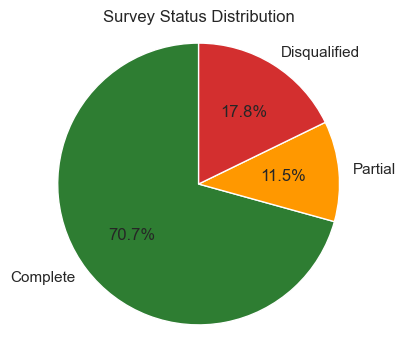

In [137]:
status_colors = {
    'Complete': '#2E7D32',
    'Partial': '#FF9800',
    'Disqualified': '#D32F2F'
}

status_counts = df['status'].value_counts().reindex(status_colors.keys())

plt.figure(figsize=(4, 4))
plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=[status_colors[s] for s in status_counts.index]
)
plt.title('Survey Status Distribution')
plt.axis('equal')
plt.show()


In [138]:
import pandas as pd

# 1. Dataset Dimensions
# Provides the total number of survey responses and variables (columns)
rows, cols = df.shape
print(f"--- 1. Dataset Scale ---")
print(f"Total Respondents: {rows}")
print(f"Total Variables: {cols}")

# 2. Data Health (Completeness)
# Shows the ratio of Complete vs. Partial responses
print(f"\n--- 2. Survey Health ---")
status_counts = df['status'].value_counts()
status_perc = df['status'].value_counts(normalize=True) * 100
for status in status_counts.index:
    print(f"{status}: {status_counts[status]} ({status_perc[status]:.1f}%)")

# 3. Demographic Breadth
# Essential for showing the diversity of the student pool
print(f"\n--- 3. Talent Pool Diversity ---")
print(f"Unique Universities: {df['university'].nunique()}")
print(f"Unique Subjects: {df['subject'].nunique()}")
print(f"Nationalities Represented: {df['nationality'].nunique()}")

# 4. Data Types Summary
# Helps identify which columns are categorical (text) vs. numeric (ratings)
print(f"\n--- 4. Column Type Overview ---")
print(df.dtypes.value_counts())

--- 1. Dataset Scale ---
Total Respondents: 2614
Total Variables: 34

--- 2. Survey Health ---
Complete: 1848 (70.7%)
Disqualified: 465 (17.8%)
Partial: 301 (11.5%)

--- 3. Talent Pool Diversity ---
Unique Universities: 25
Unique Subjects: 20
Nationalities Represented: 3

--- 4. Column Type Overview ---
object            25
float64            5
int64              2
datetime64[ns]     2
Name: count, dtype: int64


### CATEGORY 1: Question Optimization

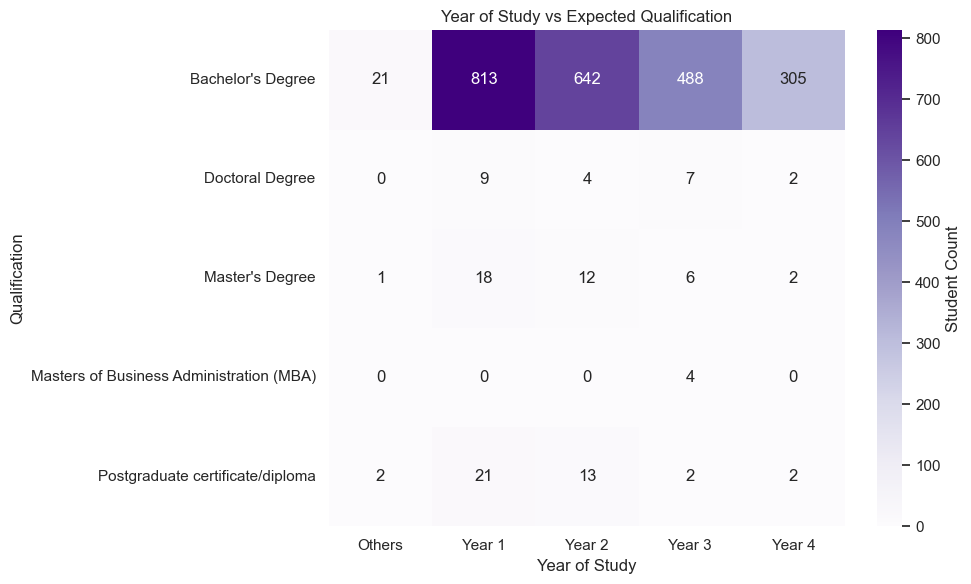

In [139]:
logic_df = pd.crosstab(df['year'], df['qualification'])

plt.figure(figsize=(10, 6))
sns.heatmap(
    logic_df.T,
    annot=True,
    fmt='d',
    cmap='Purples',
    cbar_kws={'label': 'Student Count'}
)
plt.title('Year of Study vs Expected Qualification')
plt.xlabel('Year of Study')
plt.ylabel('Qualification')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


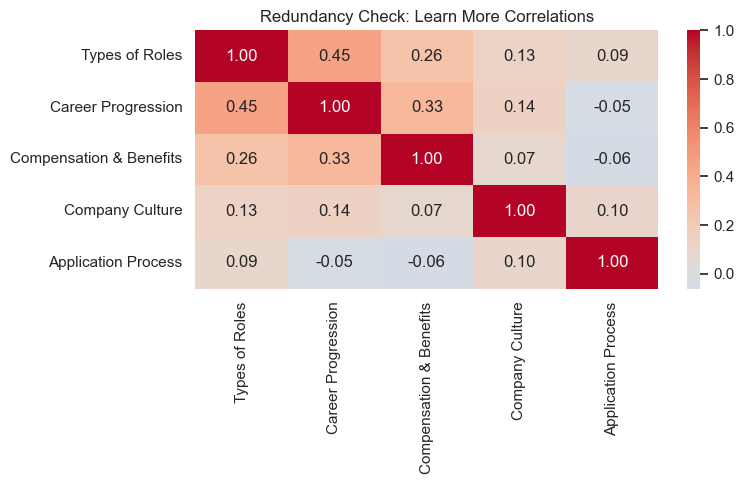

In [140]:
info_cols = ['info_roles', 'info_career', 'info_comp', 'info_culture', 'info_process']
info_binary = df[info_cols].notna().astype(int)
info_corr = info_binary.corr()

info_rename_map = {
    'info_roles': 'Types of Roles',
    'info_career': 'Career Progression',
    'info_comp': 'Compensation & Benefits',
    'info_culture': 'Company Culture',
    'info_process': 'Application Process'
}

plt.figure(figsize=(8, 5))
sns.heatmap(
    info_corr.rename(index=info_rename_map, columns=info_rename_map),
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)
plt.title('Redundancy Check: Learn More Correlations')
plt.tight_layout()
plt.show()


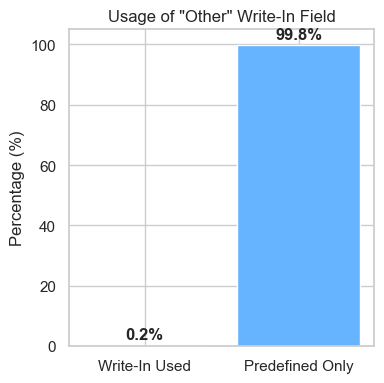

In [141]:
other_usage = df['info_other_text'].notna().mean() * 100

plt.figure(figsize=(4, 4))
plt.bar(
    ['Write-In Used', 'Predefined Only'],
    [other_usage, 100 - other_usage],
    color=['#ff9999', '#66b3ff']
)
plt.title('Usage of "Other" Write-In Field')
plt.ylabel('Percentage (%)')

for i, v in enumerate([other_usage, 100 - other_usage]):
    plt.text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.ylim(0, 105)
plt.tight_layout()
plt.show()


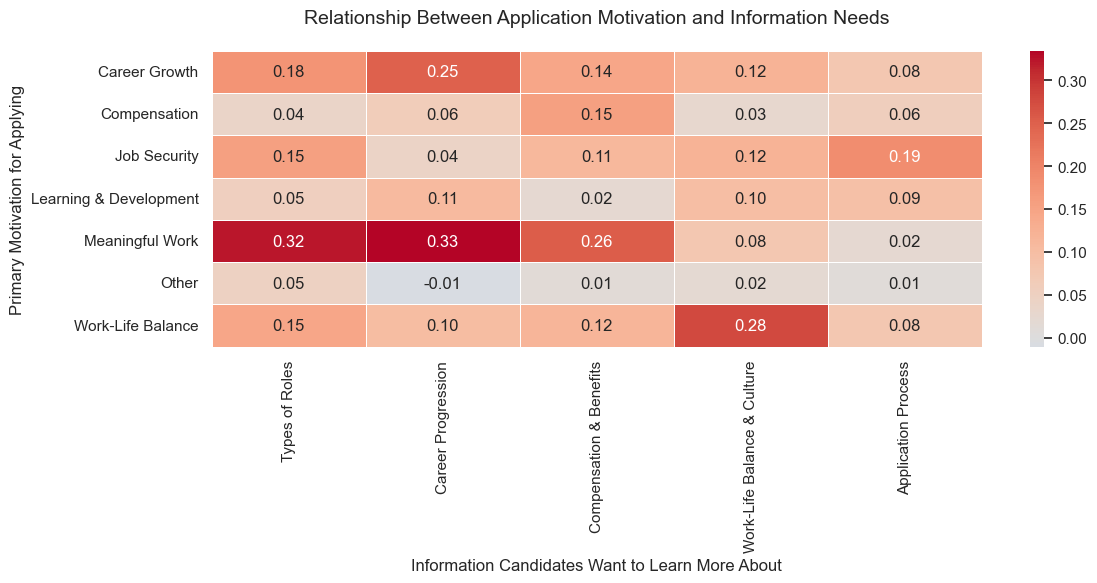

In [142]:
# ============================================================
# CLEAN + RECODE MOTIVATION × INFO INTEREST CORRELATION HEATMAP
# ============================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. One-hot encode motivation column
#    Each motivation becomes its own binary column
# ------------------------------------------------------------
motivation_dummies = pd.get_dummies(
    df['motivation'],
    prefix='motivation'
)

# ------------------------------------------------------------
# 2. Convert "info_*" columns into binary interest flags
#    1 = respondent selected this topic
#    0 = not selected
# ------------------------------------------------------------
info_cols = [
    'info_roles',
    'info_career',
    'info_comp',
    'info_culture',
    'info_process'
]

info_binary = df[info_cols].notna().astype(int)

# Rename info columns to clearer internal names
info_binary = info_binary.rename(columns={
    'info_roles': 'info_interest_roles',
    'info_career': 'info_interest_career',
    'info_comp': 'info_interest_compensation',
    'info_culture': 'info_interest_culture',
    'info_process': 'info_interest_process'
})

# ------------------------------------------------------------
# 3. Combine motivation and info interest features
# ------------------------------------------------------------
corr_input_df = pd.concat([motivation_dummies, info_binary], axis=1)

# ------------------------------------------------------------
# 4. Compute correlation matrix
#    Pearson correlation works for binary variables
# ------------------------------------------------------------
corr_matrix = corr_input_df.corr()

# Extract only Motivation × Info Interest correlations
motivation_cols = motivation_dummies.columns
info_interest_cols = info_binary.columns

motivation_info_corr = corr_matrix.loc[motivation_cols, info_interest_cols]

# ------------------------------------------------------------
# 5. Define human-readable labels for plotting
# ------------------------------------------------------------
motivation_label_map = {
    'motivation_Career growth opportunities': 'Career Growth',
    'motivation_Compensation package': 'Compensation',
    'motivation_Job security': 'Job Security',
    'motivation_Learning and development': 'Learning & Development',
    'motivation_Meaningful work impact': 'Meaningful Work',
    'motivation_Work-life balance': 'Work-Life Balance',
    'motivation_Other - Write In (Required)': 'Other'
}

info_label_map = {
    'info_interest_roles': 'Types of Roles',
    'info_interest_career': 'Career Progression',
    'info_interest_compensation': 'Compensation & Benefits',
    'info_interest_culture': 'Work-Life Balance & Culture',
    'info_interest_process': 'Application Process'
}

# Apply readable labels
motivation_info_corr_readable = motivation_info_corr.rename(
    index=motivation_label_map,
    columns=info_label_map
)

# ------------------------------------------------------------
# 6. Plot clean, business-friendly heatmap
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))

sns.heatmap(
    motivation_info_corr_readable,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    'Relationship Between Application Motivation and Information Needs',
    fontsize=14,
    pad=20
)
plt.xlabel('Information Candidates Want to Learn More About', fontsize=12)
plt.ylabel('Primary Motivation for Applying', fontsize=12)

plt.tight_layout()
plt.show()


### CATEGORY 2: Survey Status

In [143]:
analysis_vars = [
    'year', 'qualification', 'nationality',
    'gender', 'university', 'subject',
    'Language', 'is_mobile'
]

df['is_complete'] = (df['status'] == 'Complete').astype(int)
ml_df = df[analysis_vars + ['is_complete']].dropna()

X = ml_df[analysis_vars].apply(lambda c: LabelEncoder().fit_transform(c.astype(str)))
y = ml_df['is_complete']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred):.3f}")
print(f"F1-score : {f1_score(y_test, y_pred):.3f}")


Accuracy : 0.971
Precision: 0.970
Recall   : 0.993
F1-score : 0.981


Model and preprocessing objects saved:
- partial_response_model.pkl
- partial_response_label_encoders.pkl
- partial_response_feature_list.pkl

Model Performance Metrics (Partial Prediction):
Accuracy : 0.864
Precision: 0.047
Recall   : 0.211
F1-score : 0.076
ROC-AUC  : 0.577


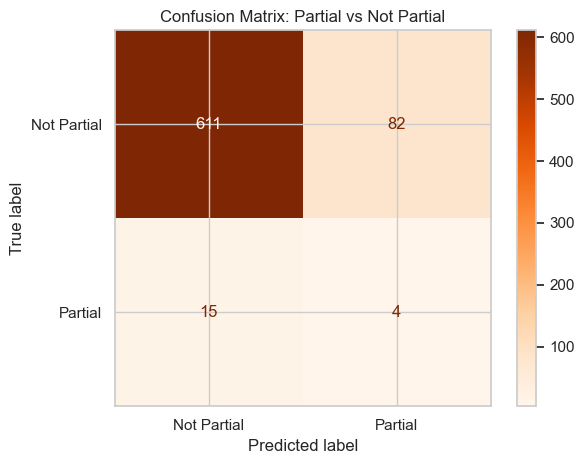

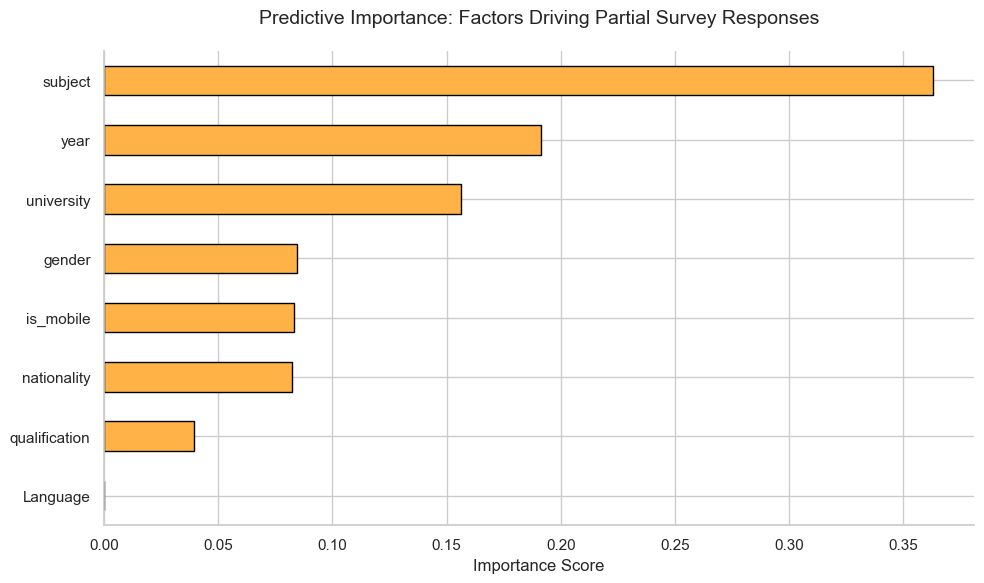

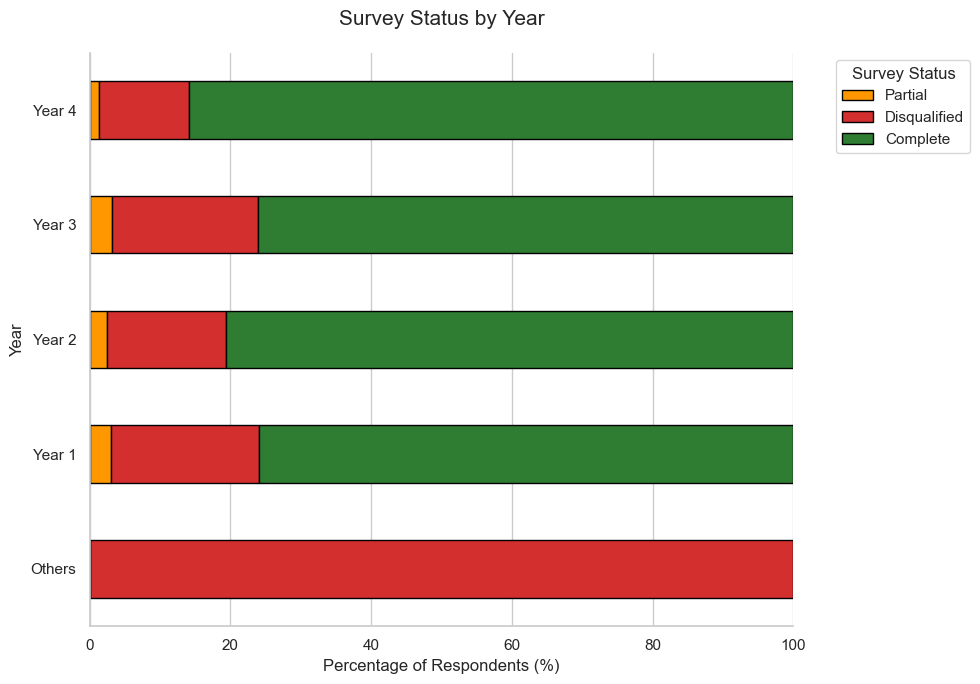

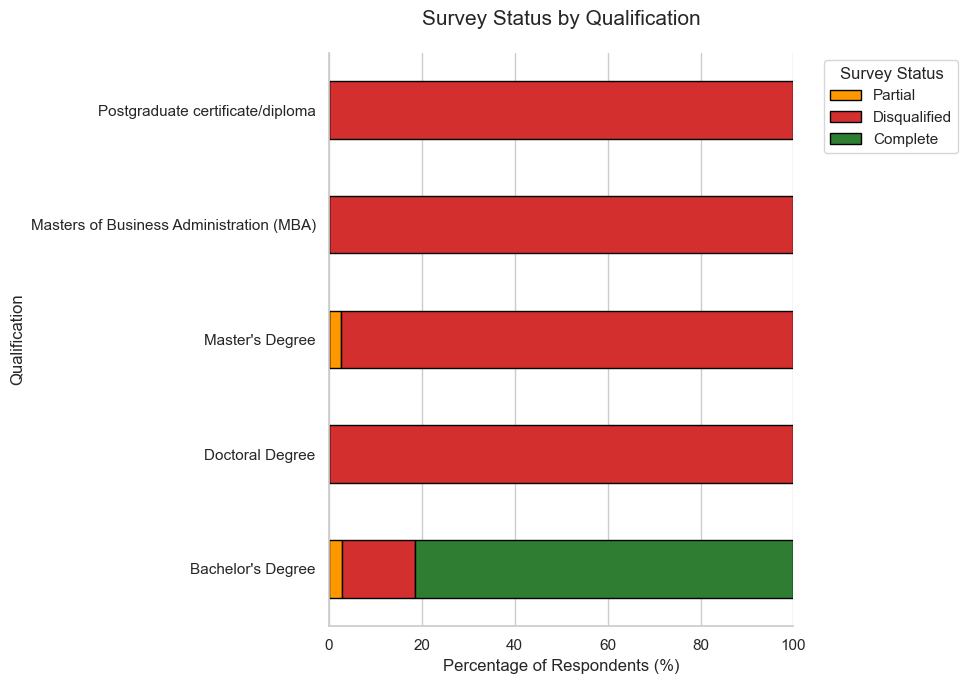

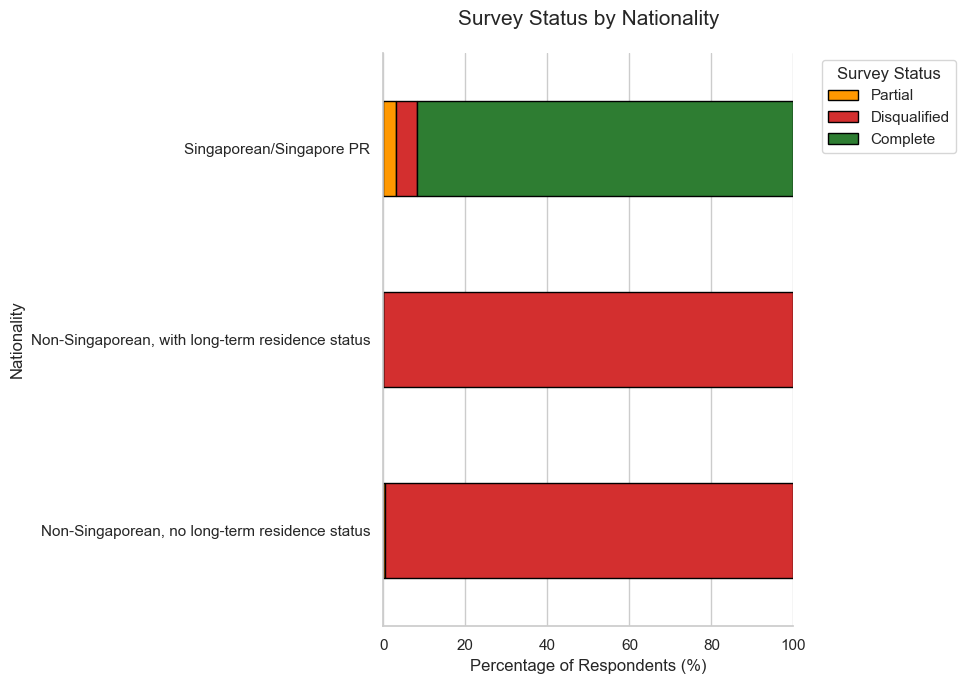

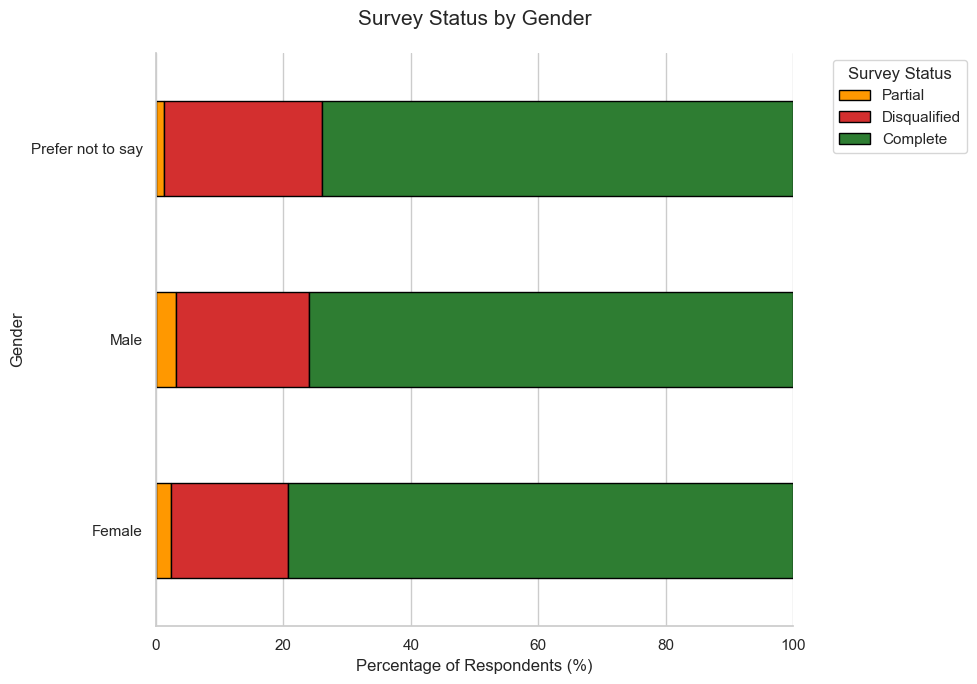

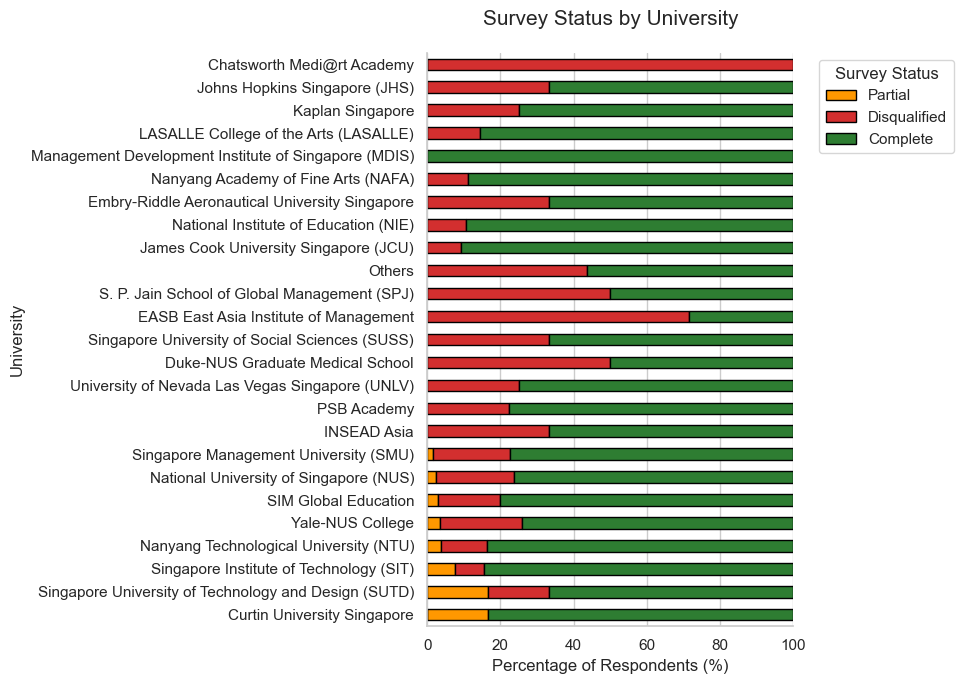

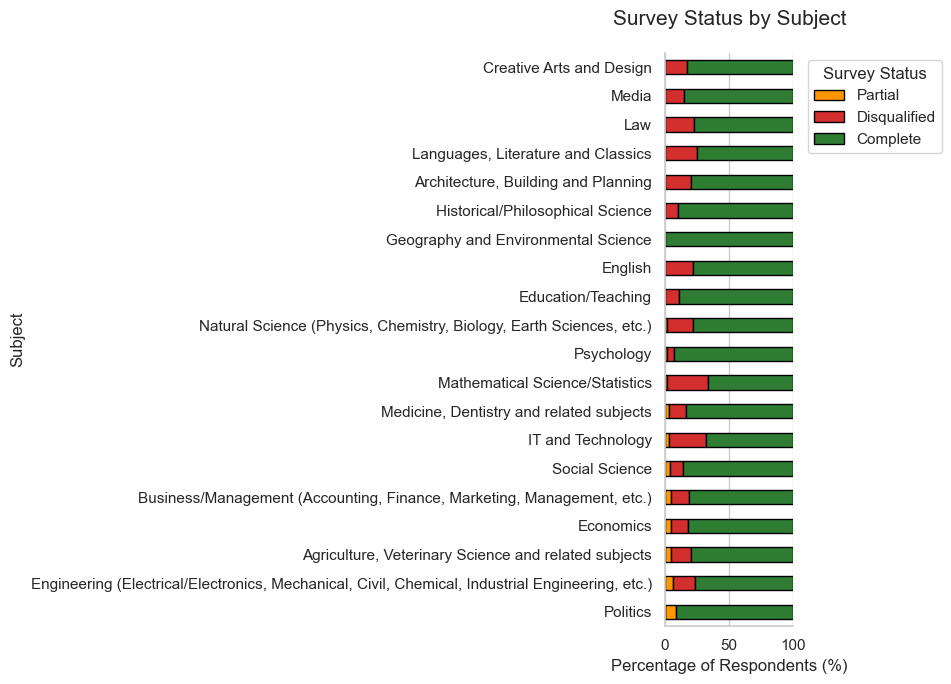

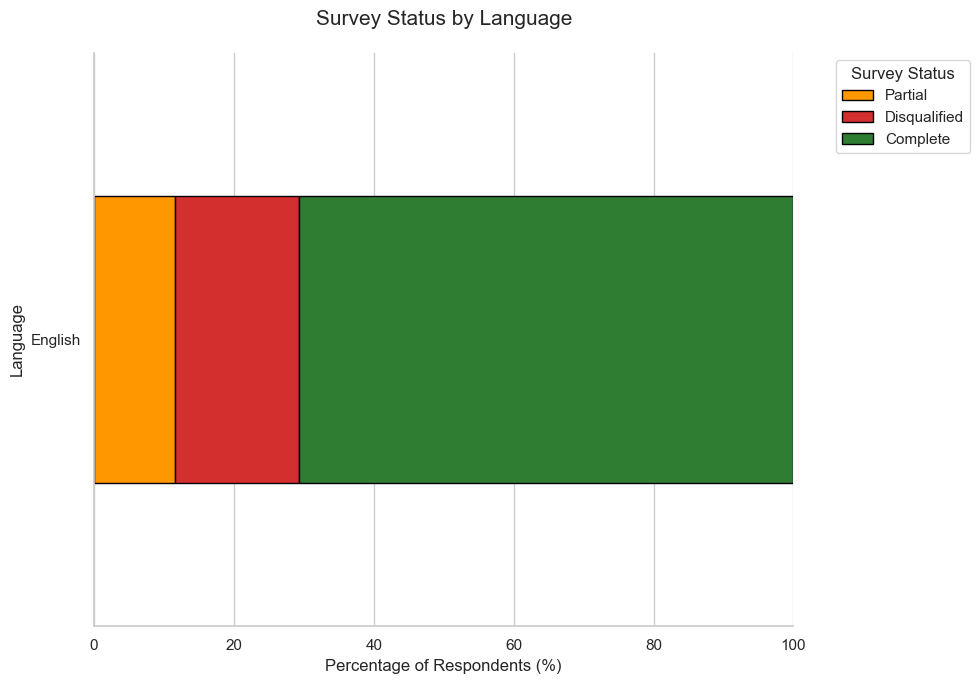

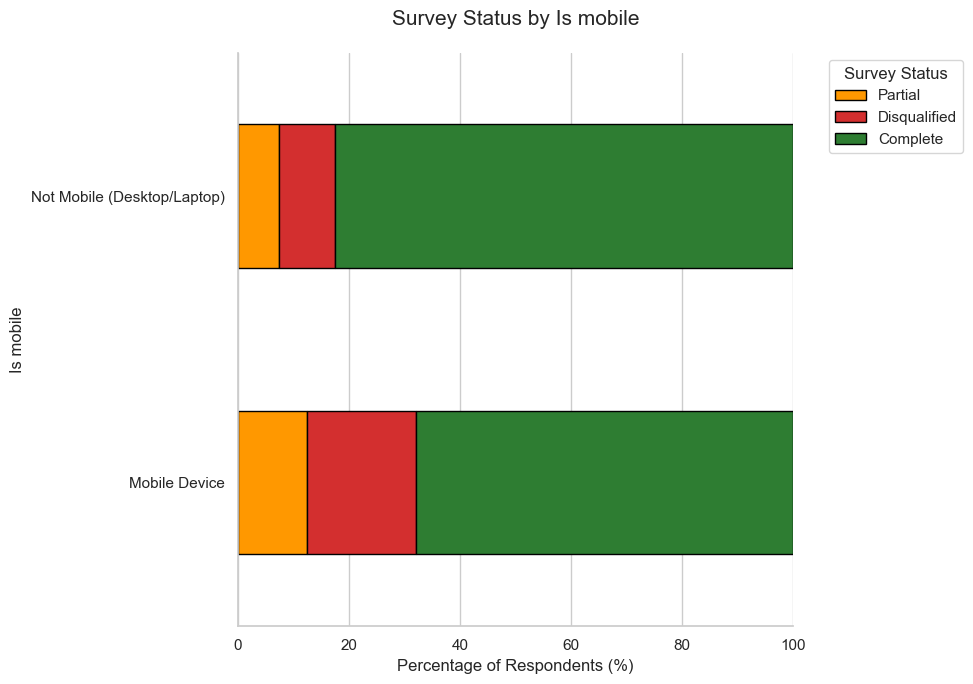

In [144]:
import pandas as pd
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Color mapping (Partial → Disqualified → Complete)
# ------------------------------------------------------------
status_colors = {
    'Partial': '#FF9800',
    'Disqualified': '#D32F2F',
    'Complete': '#2E7D32'
}
status_order = ['Partial', 'Disqualified', 'Complete']

# ------------------------------------------------------------
# Feature Selection
# ------------------------------------------------------------
analysis_vars = [
    'year',
    'qualification',
    'nationality',
    'gender',
    'university',
    'subject',
    'Language',
    'is_mobile'
]

# Mobile label for plotting
df['is_mobile_label'] = df['is_mobile'].map({
    0: 'Not Mobile (Desktop/Laptop)',
    1: 'Mobile Device'
})

# ------------------------------------------------------------
# Target Variable: PARTIAL vs NOT PARTIAL
# ------------------------------------------------------------
df['is_partial'] = (df['status'] == 'Partial').astype(int)

ml_data = df[analysis_vars + ['is_partial']].dropna()

X = ml_data[analysis_vars].copy()
y = ml_data['is_partial']

# ------------------------------------------------------------
# Encode categorical variables and STORE encoders
# ------------------------------------------------------------
label_encoders = {}

for col in analysis_vars:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le  # save encoder

# ------------------------------------------------------------
# Train / Test Split
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------
# Train Random Forest Model
# ------------------------------------------------------------
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train, y_train)

# ------------------------------------------------------------
# SAVE MODEL + ENCODERS
# ------------------------------------------------------------
joblib.dump(rf, 'partial_response_model.pkl')
joblib.dump(label_encoders, 'partial_response_label_encoders.pkl')
joblib.dump(analysis_vars, 'partial_response_feature_list.pkl')

print("Model and preprocessing objects saved:")
print("- partial_response_model.pkl")
print("- partial_response_label_encoders.pkl")
print("- partial_response_feature_list.pkl")

# ------------------------------------------------------------
# Prediction & Metrics
# ------------------------------------------------------------
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("\nModel Performance Metrics (Partial Prediction):")
print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1-score : {f1:.3f}")
print(f"ROC-AUC  : {roc_auc:.3f}")

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Partial', 'Partial']
)
disp.plot(cmap='Oranges')
plt.title('Confusion Matrix: Partial vs Not Partial')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Feature Importance Plot
# ------------------------------------------------------------
importances = pd.Series(
    rf.feature_importances_,
    index=analysis_vars
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(
    kind='barh',
    color='#FFB347',
    edgecolor='black'
)
plt.title(
    'Predictive Importance: Factors Driving Partial Survey Responses',
    fontsize=14,
    pad=20
)
plt.xlabel('Importance Score')
sns.despine()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Status Distribution Plots
# University, Subject, Mobile sorted by PARTIAL rate
# ------------------------------------------------------------
sort_by_partial_vars = ['university', 'subject', 'is_mobile']

for col in analysis_vars:
    plt.figure(figsize=(10, 7))
    
    col_to_plot = 'is_mobile_label' if col == 'is_mobile' else col
    
    status_dist = (
        pd.crosstab(df[col_to_plot], df['status'], normalize='index') * 100
    )

    available_statuses = [s for s in status_order if s in status_dist.columns]
    status_dist = status_dist[available_statuses]

    if col in sort_by_partial_vars and 'Partial' in status_dist.columns:
        status_dist = status_dist.sort_values(by='Partial', ascending=False)

    status_dist.plot(
        kind='barh',
        stacked=True,
        ax=plt.gca(),
        color=[status_colors[s] for s in available_statuses],
        edgecolor='black'
    )

    plt.title(f'Survey Status by {col.replace("_", " ").capitalize()}', fontsize=15, pad=20)
    plt.xlabel('Percentage of Respondents (%)')
    plt.ylabel(col.replace("_", " ").capitalize())
    plt.xlim(0, 100)
    plt.yticks(rotation=0)

    plt.legend(title='Survey Status', bbox_to_anchor=(1.05, 1), loc='upper left')
    sns.despine()
    plt.tight_layout()
    plt.show()


/var/folders/mb/9y6pxy613_x_ync4yzkhl_1m0000gn/T/ipykernel_22973/1199247553.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x='duration_sec', y='status', data=df[df['duration_sec'] <= 600],


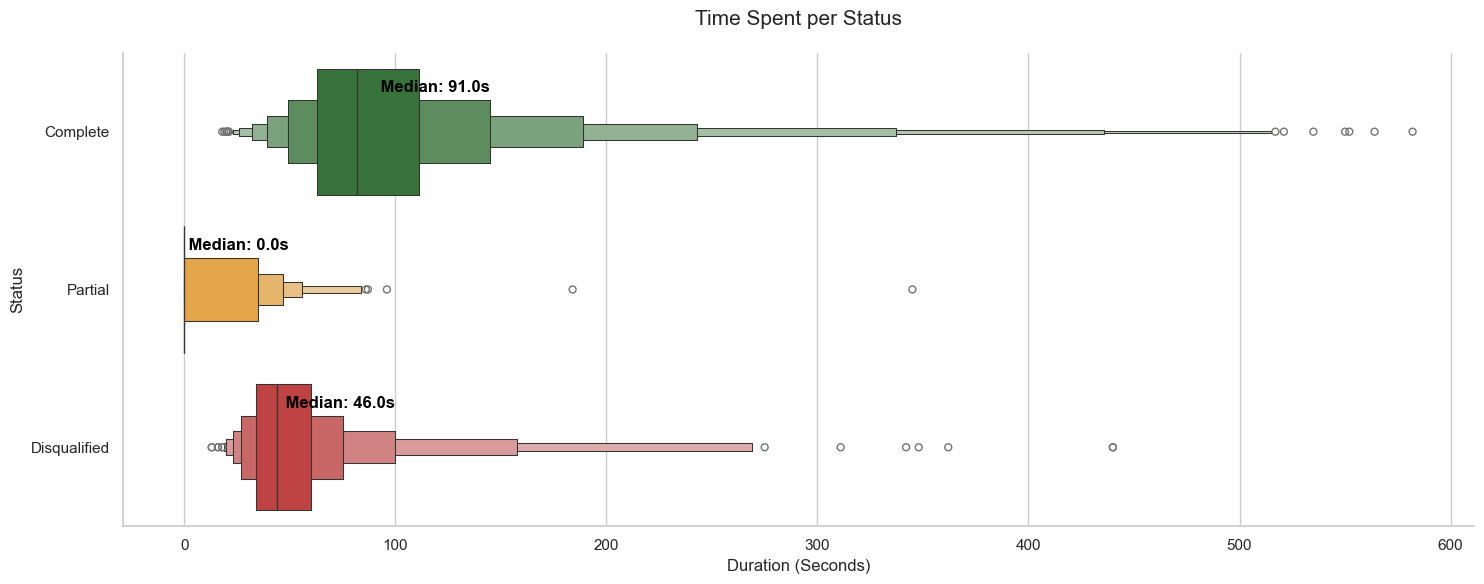

In [145]:
plt.figure(figsize=(15, 6))

# Boxen plot is great for large data and shows distribution depth
sns.boxenplot(x='duration_sec', y='status', data=df[df['duration_sec'] <= 600],
              order=['Complete', 'Partial', 'Disqualified'],
              palette=status_colors)

plt.title('Time Spent per Status', fontsize=15, pad=20)
plt.xlabel('Duration (Seconds)', fontsize=12)
plt.ylabel('Status', fontsize=12)

# Add median text labels
for i, status in enumerate(['Complete', 'Partial', 'Disqualified']):
    med = df[df['status'] == status]['duration_sec'].median()
    plt.text(med, i - 0.25, f' Median: {med:.1f}s', fontweight='bold', color='black')

sns.despine()
plt.tight_layout()
plt.show()

/var/folders/mb/9y6pxy613_x_ync4yzkhl_1m0000gn/T/ipykernel_22973/491672194.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


     question  num_dropoffs  percentage
0  university           237       78.74
1  perception            62       20.60
2        year             1        0.33
3  info_roles             1        0.33


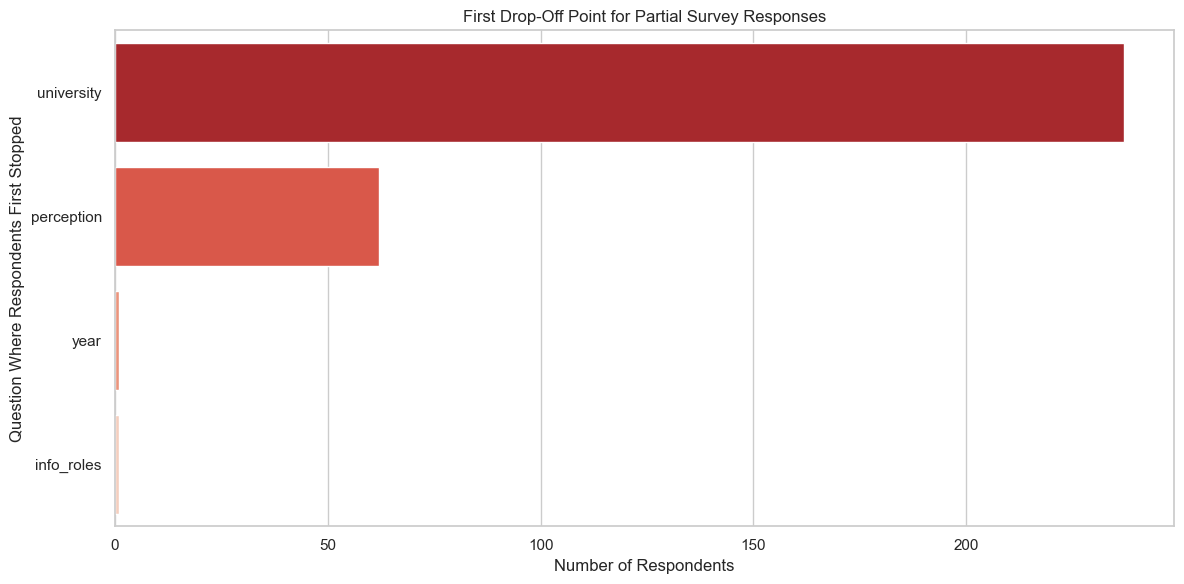

In [146]:
# ============================================
# ANALYSE DROP-OFF POINTS FOR PARTIAL RESPONSES
# ============================================

# ------------------------------------------------
# 1. Define the survey question order
#    This MUST reflect the actual order shown to respondents
# ------------------------------------------------
survey_questions = [
    'university',
    'year',
    'qualification',
    'subject',
    'nationality',
    'gender',
    'perception',
    'info_roles',
    'info_career',
    'info_comp',
    'info_culture',
    'info_process',
    'info_other_text',
    'attractiveness',
    'motivation',
    'motivation_other'
]

# ------------------------------------------------
# 2. Filter only Partial responses
# ------------------------------------------------
partial_df = df[df['status'] == 'Partial'].copy()

# ------------------------------------------------
# 3. Function to find the first unanswered question
#    For each respondent, we scan questions in order
#    and return the first question that is blank or NaN
# ------------------------------------------------
def first_blank_question(row):
    for q in survey_questions:
        if pd.isna(row[q]) or str(row[q]).strip() == "":
            return q
    return None  # Respondent answered all listed questions

# Apply the function row-by-row
partial_df['first_dropoff_question'] = partial_df.apply(
    first_blank_question,
    axis=1
)

# ------------------------------------------------
# 4. Aggregate results to see where respondents drop off
# ------------------------------------------------
dropoff_summary = (
    partial_df['first_dropoff_question']
    .value_counts()
    .reset_index()
)

dropoff_summary.columns = ['question', 'num_dropoffs']

# Calculate percentage contribution of each drop-off point
dropoff_summary['percentage'] = (
    dropoff_summary['num_dropoffs'] /
    dropoff_summary['num_dropoffs'].sum() * 100
).round(2)

# Display the summary table
print(dropoff_summary)

# ------------------------------------------------
# 5. Visualise drop-off "cliffs"
#    This shows which question causes the most exits
# ------------------------------------------------
plt.figure(figsize=(12, 6))

sns.barplot(
    data=dropoff_summary,
    x='num_dropoffs',
    y='question',
    palette='Reds_r'
)

plt.title('First Drop-Off Point for Partial Survey Responses')
plt.xlabel('Number of Respondents')
plt.ylabel('Question Where Respondents First Stopped')

plt.tight_layout()
plt.show()


### CATEGORY 3: Demographics and Behaviorial Segmentation

#### Analysis 1: Interest-Based Personas

Description: Segment respondents based on their interests and hobbies to create interest-based personas. This can help in tailoring survey design strategies and inspecting quality insights.

/var/folders/mb/9y6pxy613_x_ync4yzkhl_1m0000gn/T/ipykernel_22973/3600092860.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clustering_clean['persona'] = kmeans.fit_predict(X_cluster)
/var/folders/mb/9y6pxy613_x_ync4yzkhl_1m0000gn/T/ipykernel_22973/3600092860.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clustering_clean['persona_label'] = clustering_clean['persona'].map(persona_mapping)


Cluster Centers:
   info_roles  info_career     info_comp  info_culture  info_process
0    0.327402     0.516014  1.000000e+00  9.056940e-01      0.249110
1    1.000000     0.886943  1.000000e+00  3.330669e-16      0.113057
2    0.913374     0.820669  1.221245e-15  7.689970e-01      0.490881

Persona Labels: ['Compensation & Culture Focused', 'Roles & Compensation Focused', 'Roles & Career Focused']

Cluster sizes: persona
0    562
1    628
2    658
Name: count, dtype: int64


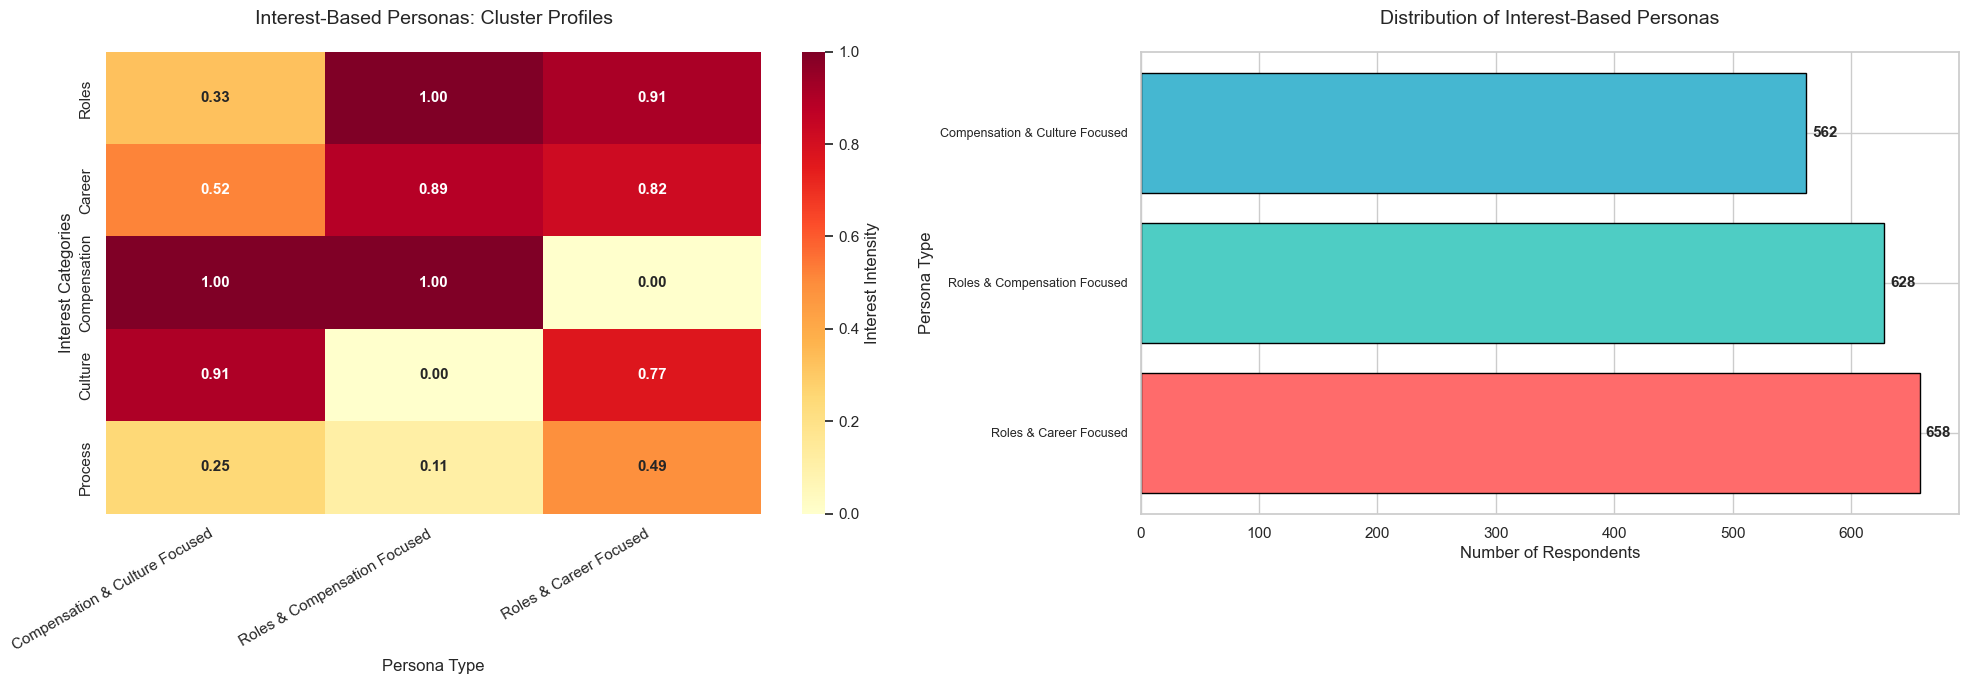

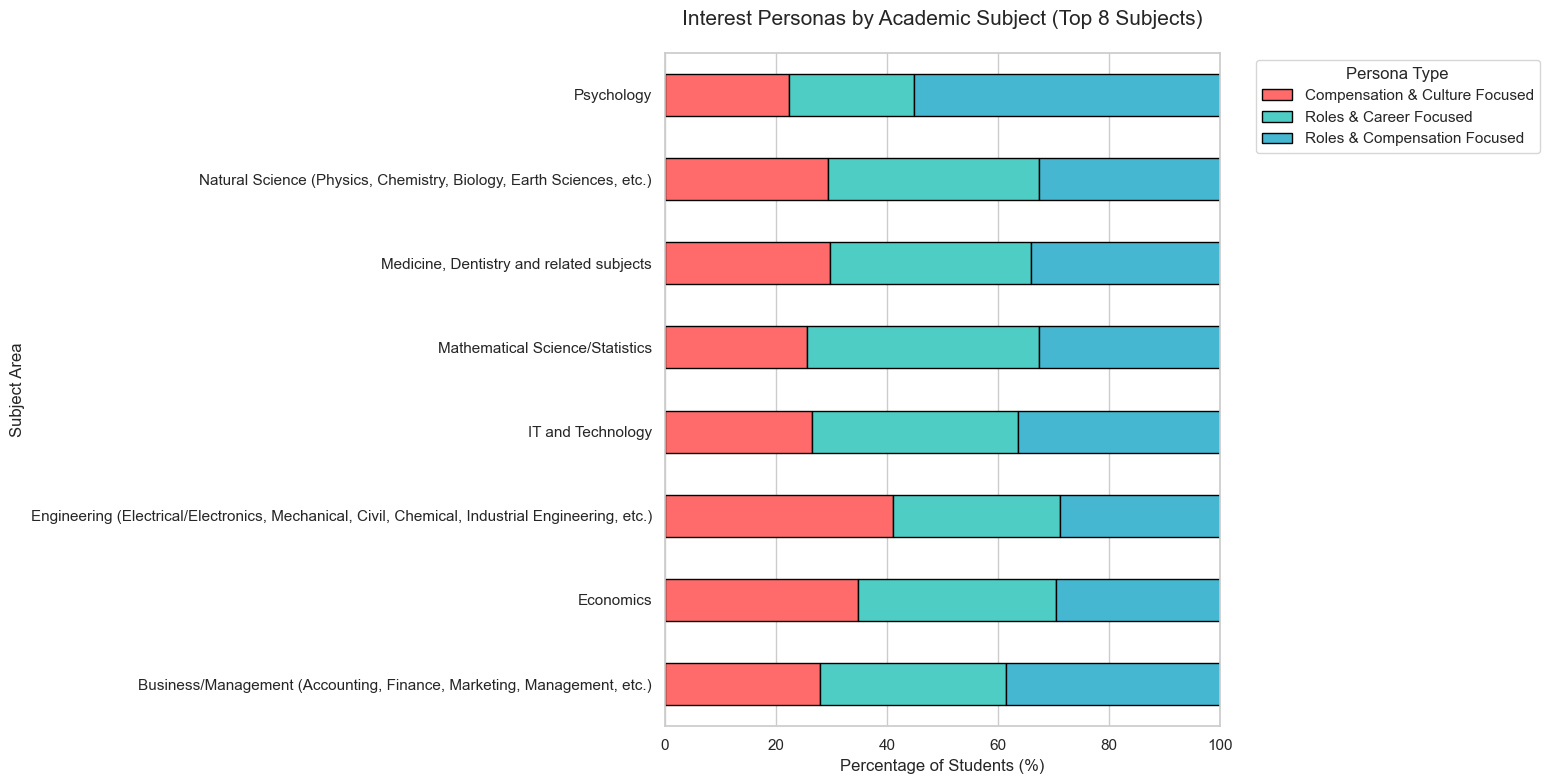


Persona Statistics by Subject:
persona_label                                       Compensation & Culture Focused  \
subject                                                                              
Agriculture, Veterinary Science and related sub...                               9   
Architecture, Building and Planning                                             16   
Business/Management (Accounting, Finance, Marke...                              66   
Creative Arts and Design                                                        10   
Economics                                                                       41   
Education/Teaching                                                              12   
Engineering (Electrical/Electronics, Mechanical...                              57   
English                                                                          8   
Geography and Environmental Science                                             13   
Historical/Philosophic

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")

# Create binary features for "Learn More" interests
info_cols = ['info_roles', 'info_career', 'info_comp', 'info_culture', 'info_process']
clustering_data = df[info_cols + ['subject', 'attractiveness']].copy()
clustering_data[info_cols] = clustering_data[info_cols].notnull().astype(int)
clustering_clean = clustering_data.dropna(subset=['subject', 'attractiveness']) 

# Perform K-Means Clustering
X_cluster = clustering_clean[info_cols].values
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clustering_clean['persona'] = kmeans.fit_predict(X_cluster)
cluster_centers = pd.DataFrame(kmeans.cluster_centers_, columns=info_cols)
persona_labels = []

for idx, row in cluster_centers.iterrows():
    # Get top 2 interests to create more descriptive labels
    top_two = row.nlargest(2)
    top_interest = top_two.index[0]
    second_interest = top_two.index[1]
    
    interest_names = {
        'info_roles': 'Roles',
        'info_career': 'Career',
        'info_comp': 'Compensation',
        'info_culture': 'Culture',
        'info_process': 'Process'
    }
    
    # Create descriptive labels based on top 2 interests
    top_name = interest_names[top_interest]
    second_name = interest_names[second_interest]
    
    label = f"{top_name} & {second_name} Focused"
    
    persona_labels.append(label)

seen_labels = {}
unique_labels = []
for i, label in enumerate(persona_labels):
    if label in seen_labels:
        seen_labels[label] += 1
        unique_labels.append(f"{label.replace(' Focused', '')} (Profile {seen_labels[label]})")
    else:
        seen_labels[label] = 1
        unique_labels.append(label)

persona_labels = unique_labels

persona_mapping = {i: persona_labels[i] for i in range(3)}
clustering_clean['persona_label'] = clustering_clean['persona'].map(persona_mapping)

print("Cluster Centers:")
print(cluster_centers)
print("\nPersona Labels:", persona_labels)
print("\nCluster sizes:", clustering_clean['persona'].value_counts().sort_index())

### Visualization 3.1.1: Cluster Centers Heatmap
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Heatmap of cluster characteristics
sns.heatmap(cluster_centers.T, annot=True, fmt='.2f', cmap='YlOrRd', 
            xticklabels=[persona_labels[i] for i in range(3)],
            yticklabels=['Roles', 'Career', 'Compensation', 'Culture', 'Process'],
            ax=axes[0], cbar_kws={'label': 'Interest Intensity'},
            annot_kws={'size': 11, 'weight': 'bold'})
axes[0].set_title('Interest-Based Personas: Cluster Profiles', fontsize=14, pad=20)
axes[0].set_xlabel('Persona Type', fontsize=12)
axes[0].set_ylabel('Interest Categories', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')


# Persona distribution
persona_counts = clustering_clean['persona_label'].value_counts()
colors_persona = ['#FF6B6B', '#4ECDC4', '#45B7D1']
axes[1].barh(persona_counts.index, persona_counts.values, color=colors_persona, edgecolor='black')
axes[1].set_title('Distribution of Interest-Based Personas', fontsize=14, pad=20)
axes[1].set_xlabel('Number of Respondents', fontsize=12)
axes[1].set_ylabel('Persona Type', fontsize=12)

axes[1].tick_params(axis='y', labelsize=9)
plt.setp(axes[1].get_yticklabels(), rotation=0, ha='right')

for i, v in enumerate(persona_counts.values):
    axes[1].text(v + 5, i, str(v), va='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# Visualization 3.1.2: Personas by Subject (Are IT students more $ focused?)
plt.figure(figsize=(16, 8))
subject_persona = pd.crosstab(clustering_clean['subject'], 
                            clustering_clean['persona_label'], 
                            normalize='index') * 100

# Get top subjects by count
top_subjects = clustering_clean['subject'].value_counts().head(8).index
subject_persona_top = subject_persona.loc[subject_persona.index.isin(top_subjects)]

subject_persona_top.plot(kind='barh', stacked=True, 
                        color=colors_persona, 
                        edgecolor='black', ax=plt.gca())
plt.title('Interest Personas by Academic Subject (Top 8 Subjects)', fontsize=15, pad=20)
plt.xlabel('Percentage of Students (%)', fontsize=12)
plt.ylabel('Subject Area', fontsize=12)
plt.xlim(0, 100)
plt.legend(title='Persona Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Statistical summary
print("\nPersona Statistics by Subject:")
persona_subject_stats = clustering_clean.groupby(['subject', 'persona_label']).size().unstack(fill_value=0)
print(persona_subject_stats.head(10))

#### Analysis 2: The Graduation "Maturity" Shift

Description: Analyze how respondents' priorities and preferences change as they approach graduation. This can provide insights into how to better engage students at different stages of their academic journey.

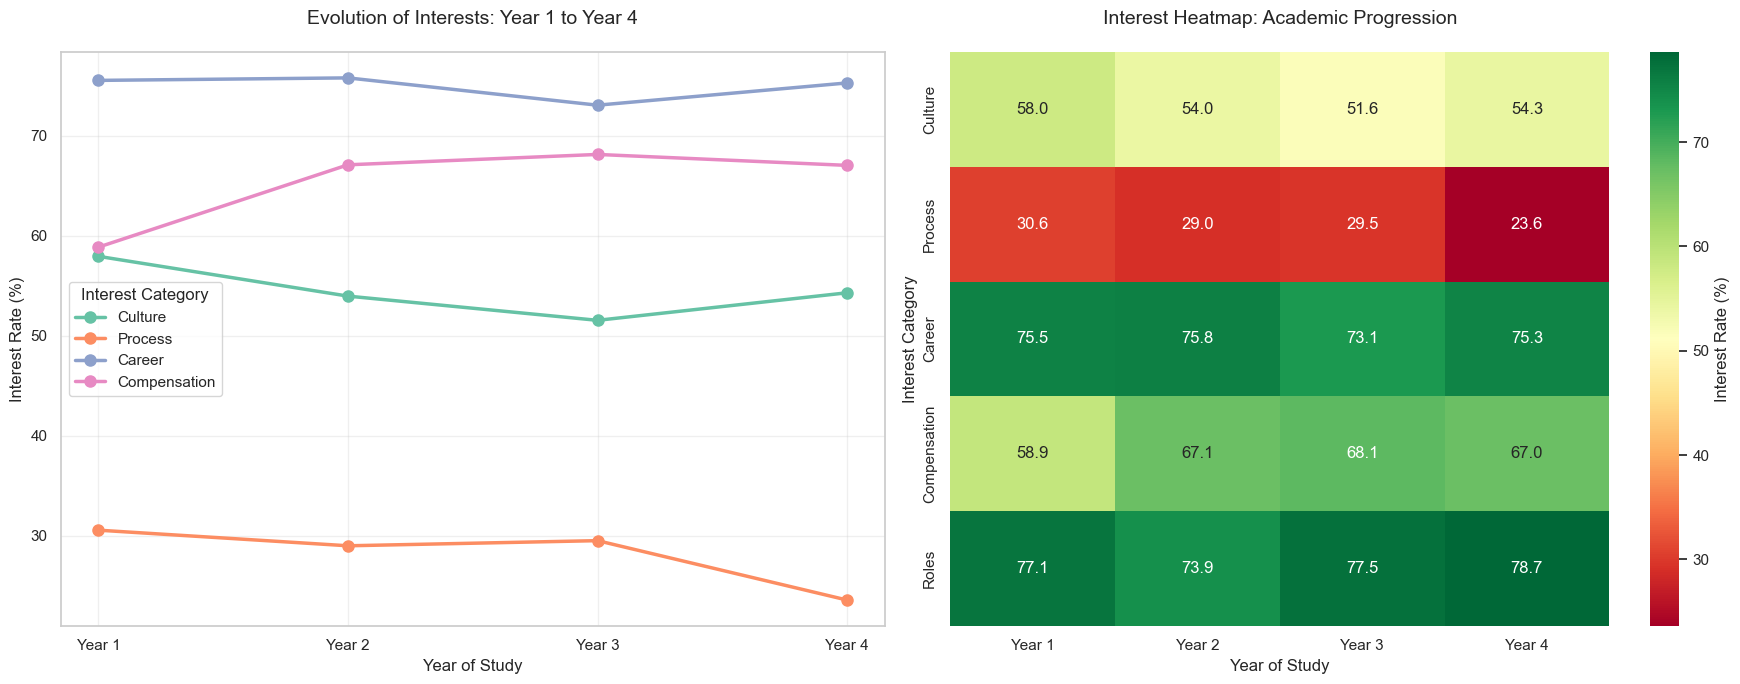

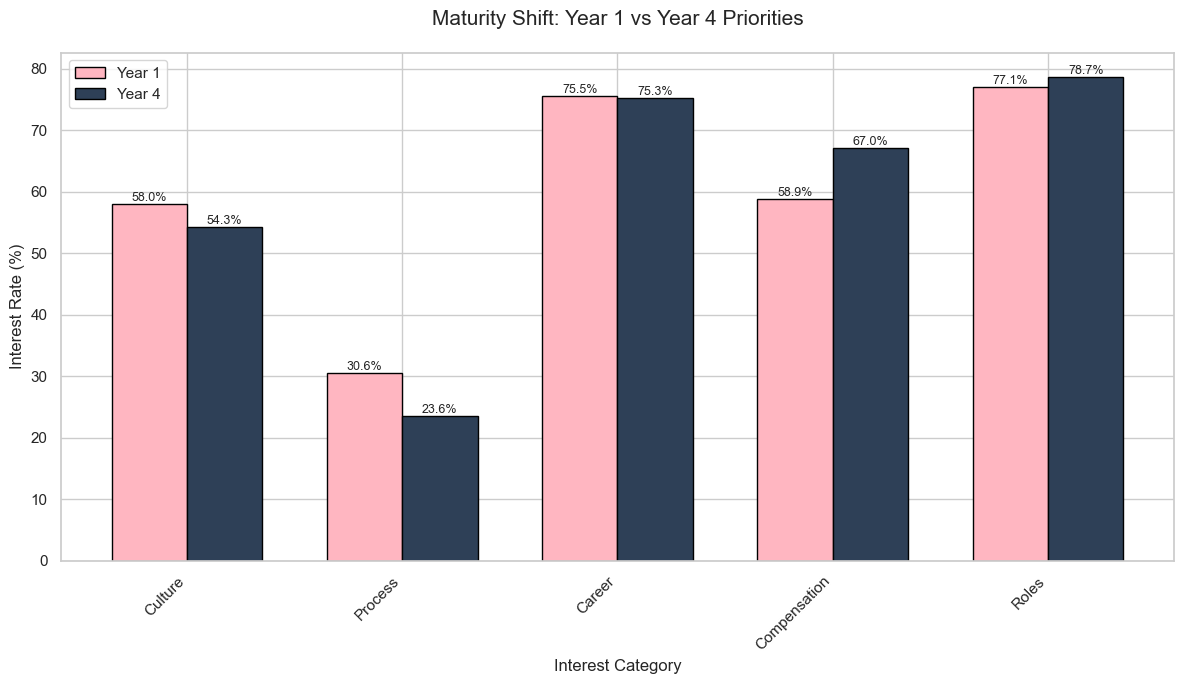


Year 1 to Year 4 Change (percentage points):
Compensation    8.172697
Roles           1.587465
Career         -0.254269
Culture        -3.643954
Process        -6.985534
dtype: float64


In [148]:
maturity_data = df[df['status'] == 'Complete'].copy()
maturity_data = maturity_data[maturity_data['year'].isin(['Year 1', 'Year 2', 'Year 3', 'Year 4'])]

# Calculate interest rates by year
year_interests = {}
for year in ['Year 1', 'Year 2', 'Year 3', 'Year 4']:
    year_df = maturity_data[maturity_data['year'] == year]
    year_interests[year] = {
        'Culture': (year_df['info_culture'].notnull().sum() / len(year_df)) * 100,
        'Process': (year_df['info_process'].notnull().sum() / len(year_df)) * 100,
        'Career': (year_df['info_career'].notnull().sum() / len(year_df)) * 100,
        'Compensation': (year_df['info_comp'].notnull().sum() / len(year_df)) * 100,
        'Roles': (year_df['info_roles'].notnull().sum() / len(year_df)) * 100,
    }

year_interest_df = pd.DataFrame(year_interests).T

# Visualization 3.2.1: Line plot showing evolution
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

key_categories = ['Culture', 'Process', 'Career', 'Compensation']
for category in key_categories:
    axes[0].plot(year_interest_df.index, year_interest_df[category], 
                 marker='o', linewidth=2.5, markersize=8, label=category)

axes[0].set_title('Evolution of Interests: Year 1 to Year 4', fontsize=14, pad=20)
axes[0].set_xlabel('Year of Study', fontsize=12)
axes[0].set_ylabel('Interest Rate (%)', fontsize=12)
axes[0].legend(title='Interest Category', loc='best')
axes[0].grid(True, alpha=0.3)

# Heatmap showing all interests by year
sns.heatmap(year_interest_df.T, annot=True, fmt='.1f', cmap='RdYlGn', 
            ax=axes[1], cbar_kws={'label': 'Interest Rate (%)'})
axes[1].set_title('Interest Heatmap: Academic Progression', fontsize=14, pad=20)
axes[1].set_xlabel('Year of Study', fontsize=12)
axes[1].set_ylabel('Interest Category', fontsize=12)

plt.tight_layout()
plt.show()

# Visualization 3.2.2: Year 1 vs Year 4 Direct Comparison
plt.figure(figsize=(12, 7))
year_comparison = year_interest_df.loc[['Year 1', 'Year 4']].T
x = np.arange(len(year_comparison.index))
width = 0.35

bars1 = plt.bar(x - width/2, year_comparison['Year 1'], width, 
                label='Year 1', color='#FFB6C1', edgecolor='black')
bars2 = plt.bar(x + width/2, year_comparison['Year 4'], width, 
                label='Year 4', color='#2E4057', edgecolor='black')

plt.xlabel('Interest Category', fontsize=12)
plt.ylabel('Interest Rate (%)', fontsize=12)
plt.title('Maturity Shift: Year 1 vs Year 4 Priorities', fontsize=15, pad=20)
plt.xticks(x, year_comparison.index, rotation=45, ha='right')
plt.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Calculate percentage change
print("\nYear 1 to Year 4 Change (percentage points):")
change = year_interest_df.loc['Year 4'] - year_interest_df.loc['Year 1']
print(change.sort_values(ascending=False))

#### Analysis 3: Institution-Specific Profiles

Description: Create detailed profiles for respondents from different institutions. This can help in understanding institution-specific needs and preferences, allowing for more targeted survey designs.

<Figure size 1400x700 with 0 Axes>

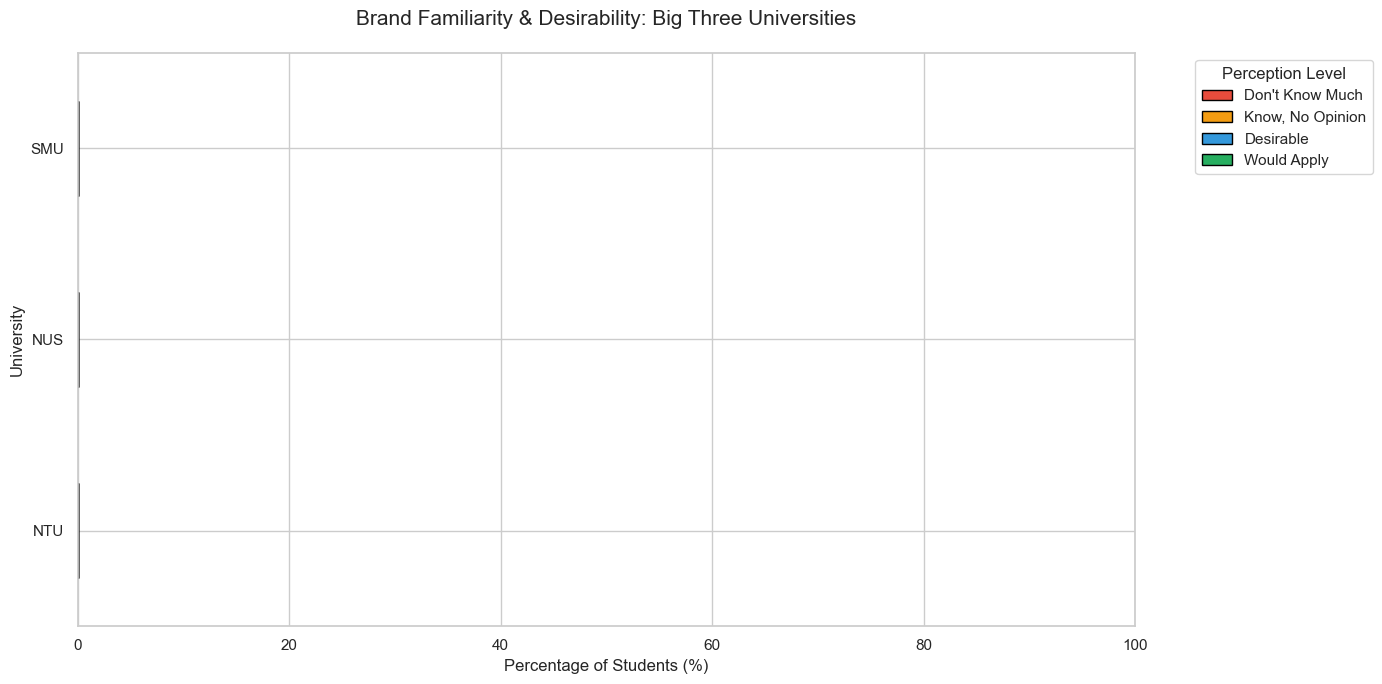

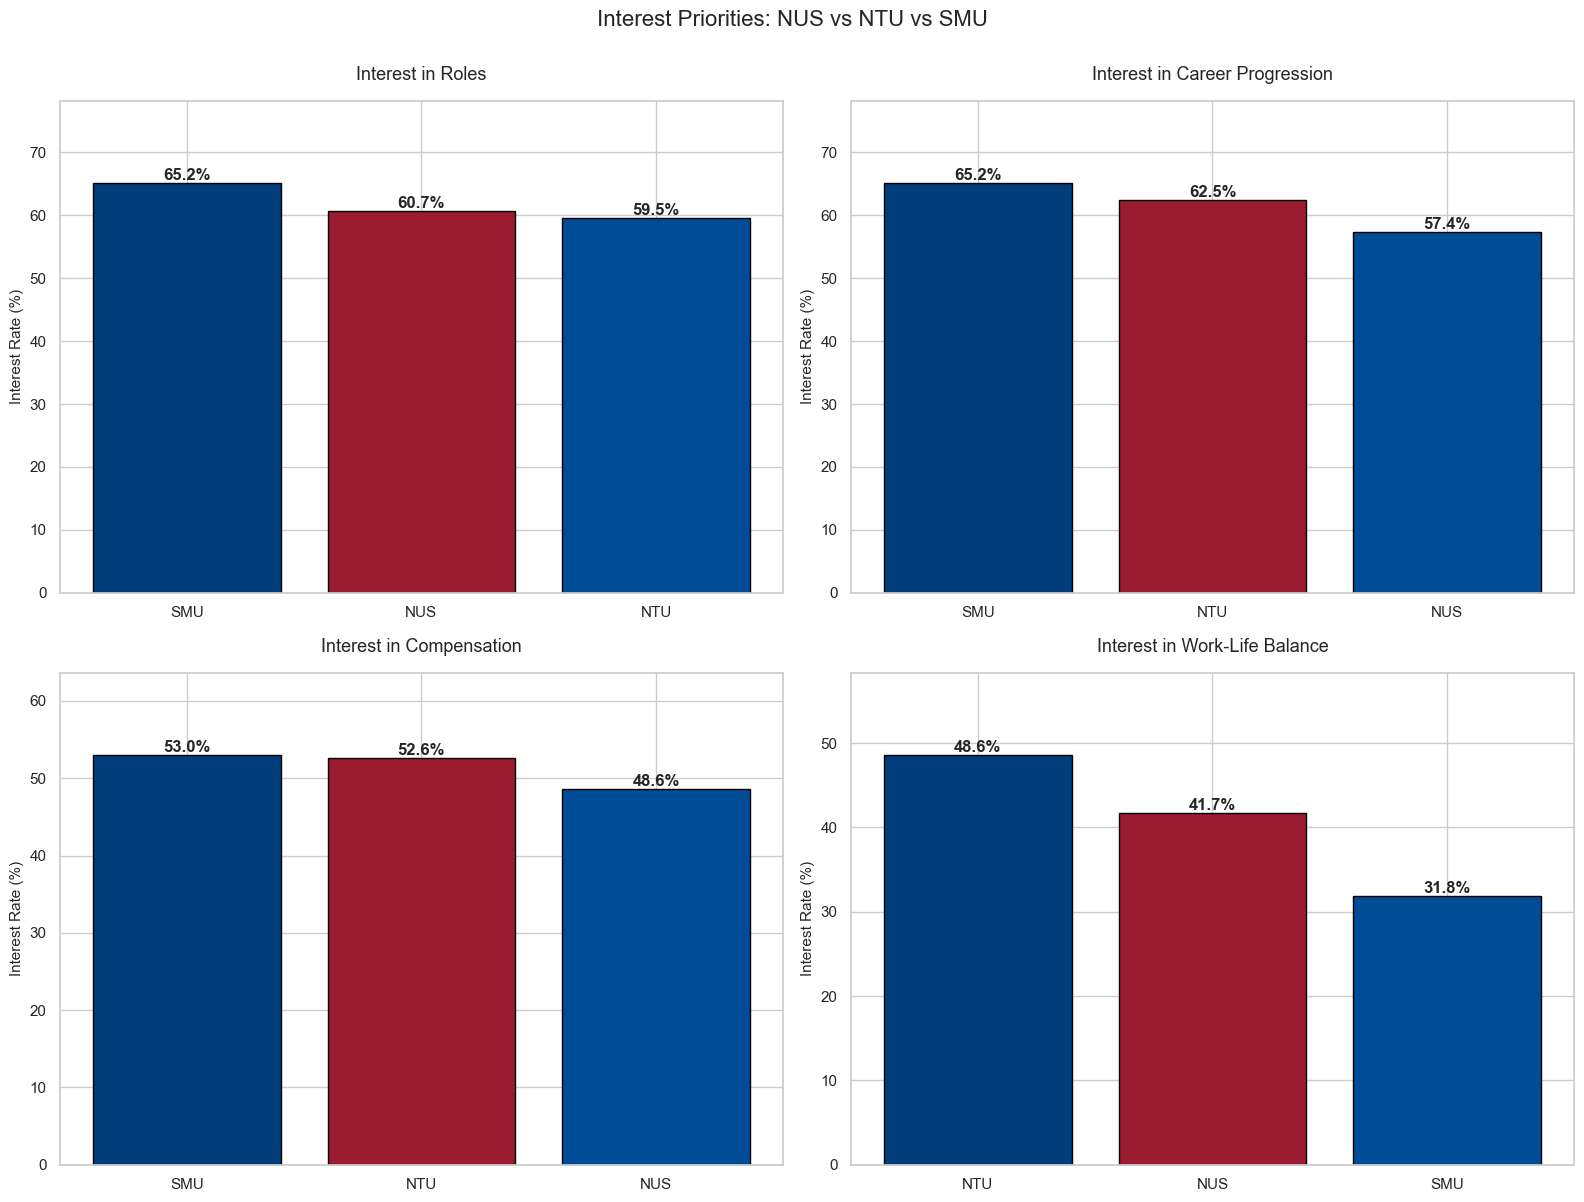

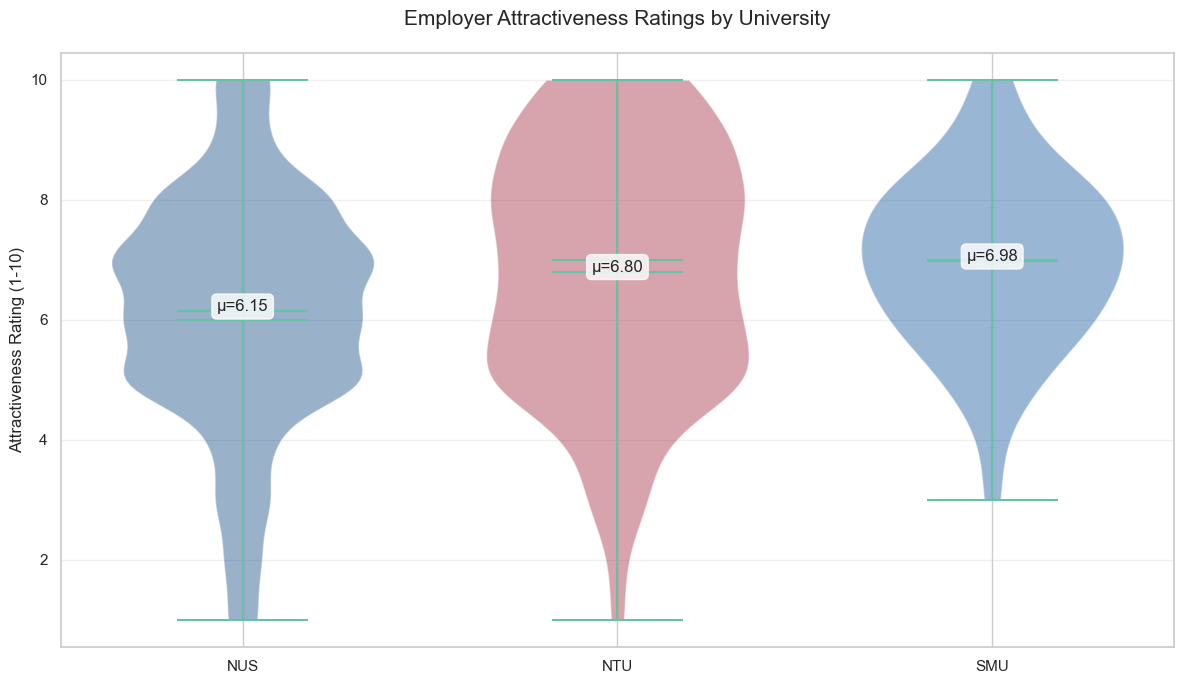


University Statistics:
            count      mean       std  min  25%  50%  75%   max
uni_short                                                      
NTU         424.0  6.804245  2.043702  1.0  5.0  7.0  8.0  10.0
NUS        1199.0  6.145955  1.960686  1.0  5.0  6.0  7.0  10.0
SMU          51.0  6.980392  1.435133  3.0  6.0  7.0  8.0  10.0


In [149]:
# Filter for Big Three universities
big_three = ['National University of Singapore (NUS)', 
             'Nanyang Technological University (NTU)', 
             'Singapore Management University (SMU)']

uni_data = df[df['university'].isin(big_three)].copy()

uni_data['uni_short'] = uni_data['university'].map({
    'National University of Singapore (NUS)': 'NUS',
    'Nanyang Technological University (NTU)': 'NTU',
    'Singapore Management University (SMU)': 'SMU'
})

# Visualization 3.3.1: Brand Familiarity (Perception)
plt.figure(figsize=(14, 7))

perception_order = [
    'I dont know much about this organisation.',
    'I know about this organisation but have no opinion on it as an employer.',
    'I think this organisation would be a desirable place to work.',
    'I would apply for a position at this organisation.'
]

perception_uni = pd.crosstab(uni_data['uni_short'], 
                             uni_data['perception'], 
                             normalize='index') * 100

for perc in perception_order:
    if perc not in perception_uni.columns:
        perception_uni[perc] = 0

perception_uni = perception_uni[perception_order]

colors_perception = ['#E74C3C', '#F39C12', '#3498DB', '#27AE60']
perception_uni.plot(kind='barh', stacked=True, color=colors_perception, 
                    edgecolor='black', figsize=(14, 7))

plt.title('Brand Familiarity & Desirability: Big Three Universities', fontsize=15, pad=20)
plt.xlabel('Percentage of Students (%)', fontsize=12)
plt.ylabel('University', fontsize=12)
plt.xlim(0, 100)
plt.legend(title='Perception Level', bbox_to_anchor=(1.05, 1), loc='upper left', 
           labels=['Don\'t Know Much', 'Know, No Opinion', 'Desirable', 'Would Apply'])
plt.tight_layout()
plt.show()

# Visualization 3.3.2: Interest Priorities by University
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

interest_categories = {
    'Roles': 'info_roles',
    'Career Progression': 'info_career',
    'Compensation': 'info_comp',
    'Work-Life Balance': 'info_culture'
}

for idx, (name, col) in enumerate(interest_categories.items()):
    uni_interest = uni_data.groupby('uni_short')[col].apply(
        lambda x: (x.notnull().sum() / len(x)) * 100
    ).sort_values(ascending=False)
    
    bars = axes[idx].bar(uni_interest.index, uni_interest.values, 
                         color=['#003D7A', '#9B1B30', '#004C97'], edgecolor='black')
    axes[idx].set_title(f'Interest in {name}', fontsize=13, pad=15)
    axes[idx].set_ylabel('Interest Rate (%)', fontsize=11)
    axes[idx].set_ylim(0, max(uni_interest.values) * 1.2)
    
    for bar in bars:
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                      f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Interest Priorities: NUS vs NTU vs SMU', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

# Visualization 3.3.3: Attractiveness Rating by University
plt.figure(figsize=(12, 7))
uni_data_clean = uni_data.dropna(subset=['attractiveness'])

parts = plt.violinplot([uni_data_clean[uni_data_clean['uni_short'] == uni]['attractiveness'].values 
                        for uni in ['NUS', 'NTU', 'SMU']], 
                       positions=[1, 2, 3], widths=0.7, 
                       showmeans=True, showmedians=True)

colors_uni = ['#003D7A', '#9B1B30', '#004C97']
for patch, color in zip(parts['bodies'], colors_uni):
    patch.set_facecolor(color)
    patch.set_alpha(0.4)

plt.xticks([1, 2, 3], ['NUS', 'NTU', 'SMU'])
plt.ylabel('Attractiveness Rating (1-10)', fontsize=12)
plt.title('Employer Attractiveness Ratings by University', fontsize=15, pad=20)
plt.grid(axis='y', alpha=0.3)

for i, uni in enumerate(['NUS', 'NTU', 'SMU']):
    mean_val = uni_data_clean[uni_data_clean['uni_short'] == uni]['attractiveness'].mean()
    plt.text(i+1, mean_val, f'μ={mean_val:.2f}', ha='center', 
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print("\nUniversity Statistics:")
print(uni_data.groupby('uni_short')['attractiveness'].describe())

In [150]:
# Create Singaporean vs Non-Singaporean segments
nationality_data = df[df['nationality'].notna()].copy()
nationality_data['is_singaporean'] = nationality_data['nationality'].str.contains(
    'Singapore', case=False, na=False
).map({True: 'Singaporean', False: 'Non-Singaporean'})

# Check the distribution first
print("Nationality Distribution:")
print(nationality_data['is_singaporean'].value_counts())
print(f"\nTotal records: {len(nationality_data)}")

# Define interest categories mapping
interest_categories = {
    'Roles': 'info_roles',
    'Career Progression': 'info_career',
    'Compensation': 'info_comp',
    'Work-Life Balance': 'info_culture'
}

# Check if we have both groups
available_groups = nationality_data['is_singaporean'].unique()
print(f"\nAvailable nationality groups: {available_groups}")

if len(available_groups) < 2:
    print("This analysis requires both Singaporean and Non-Singaporean respondents.")
    print("Skipping nationality comparison analysis.")
else:
    # Visualization 4.1: Interest Priorities by Nationality
    plt.figure(figsize=(14, 8))
    
    interest_by_nationality = {}
    for interest_name, col in interest_categories.items():
        interest_by_nationality[interest_name] = nationality_data.groupby('is_singaporean')[col].apply(
            lambda x: (x.notnull().sum() / len(x)) * 100
        )
    
    nationality_interest_df = pd.DataFrame(interest_by_nationality)
    
    print("\nInterest rates by nationality:")
    print(nationality_interest_df)
    
    x = np.arange(len(nationality_interest_df.columns))
    width = 0.35
    
    # Check which groups exist and plot accordingly
    if 'Singaporean' in nationality_interest_df.index:
        bars1 = plt.bar(x - width/2, nationality_interest_df.loc['Singaporean'], 
                        width, label='Singaporean', color='#C41E3A', edgecolor='black')
        
        # Add value labels
        for bar in bars1:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%', ha='center', va='bottom', fontsize=9)
    
    if 'Non-Singaporean' in nationality_interest_df.index:
        bars2 = plt.bar(x + width/2, nationality_interest_df.loc['Non-Singaporean'], 
                        width, label='Non-Singaporean', color='#00247D', edgecolor='black')
        
        # Add value labels
        for bar in bars2:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%', ha='center', va='bottom', fontsize=9)
    
    plt.xlabel('Interest Category', fontsize=12)
    plt.ylabel('Interest Rate (%)', fontsize=12)
    plt.title('Interest Priorities: Singaporean vs Non-Singaporean Students', fontsize=15, pad=20)
    plt.xticks(x, nationality_interest_df.columns, rotation=30, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Visualization 4.2: Motivation Factors by Nationality
    plt.figure(figsize=(16, 10))
    
    motivation_data = nationality_data[nationality_data['motivation'].notna()]
    
    if len(motivation_data) > 0 and len(motivation_data['is_singaporean'].unique()) > 1:
        motivation_by_nat = pd.crosstab(motivation_data['is_singaporean'], 
                                         motivation_data['motivation'], 
                                         normalize='index') * 100
        
        # Get top motivations
        top_motivations = motivation_data['motivation'].value_counts().head(8).index
        motivation_by_nat_top = motivation_by_nat[[col for col in top_motivations if col in motivation_by_nat.columns]]
        
        motivation_by_nat_top.T.plot(kind='barh', color=['#C41E3A', '#00247D'], 
                                      edgecolor='black', figsize=(16, 10))
        
        plt.title('Top Motivation Factors: Singaporean vs Non-Singaporean', fontsize=15, pad=20)
        plt.xlabel('Percentage (%)', fontsize=12)
        plt.ylabel('Motivation Factor', fontsize=12)
        plt.legend(title='Nationality', loc='lower right')
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ Insufficient data for motivation comparison by nationality")
    
    # Visualization 4.3: Perception by Nationality
    plt.figure(figsize=(14, 7))
    
    # Define perception order
    perception_order = [
        'I don\'t know much about this organisation.',
        'I know about this organisation but have no opinion on it as an employer.',
        'I think this organisation would be a desirable place to work.',
        'I would apply for a position at this organisation.'
    ]
    
    perception_data = nationality_data[nationality_data['perception'].notna()]
    
    if len(perception_data) > 0 and len(perception_data['is_singaporean'].unique()) > 1:
        perception_by_nat = pd.crosstab(perception_data['is_singaporean'], 
                                         perception_data['perception'], 
                                         normalize='index') * 100
        
        # Ensure all perception types are present
        for perc in perception_order:
            if perc not in perception_by_nat.columns:
                perception_by_nat[perc] = 0
        
        perception_by_nat = perception_by_nat[perception_order]
        
        # Define colors
        colors_perception = ['#E74C3C', '#F39C12', '#3498DB', '#27AE60']
        
        perception_by_nat.plot(kind='barh', stacked=True, color=colors_perception, 
                               edgecolor='black', figsize=(14, 7))
        
        plt.title('Brand Perception by Nationality Status', fontsize=15, pad=20)
        plt.xlabel('Percentage of Students (%)', fontsize=12)
        plt.ylabel('Nationality Status', fontsize=12)
        plt.xlim(0, 100)
        plt.legend(title='Perception Level', bbox_to_anchor=(1.05, 1), loc='upper left',
                   labels=['Don\'t Know Much', 'Know, No Opinion', 'Desirable', 'Would Apply'])
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ Insufficient data for perception comparison by nationality")
    
    # Statistical summary
    print("\n" + "=" * 80)
    print("NATIONALITY SEGMENT STATISTICS")
    print("=" * 80)
    
    for group in available_groups:
        group_data = nationality_data[nationality_data['is_singaporean'] == group]
        print(f"\n{group}: {len(group_data)} respondents ({len(group_data)/len(nationality_data)*100:.1f}%)")
        
        if 'attractiveness' in group_data.columns and group_data['attractiveness'].notna().sum() > 0:
            print(f"  Average Attractiveness: {group_data['attractiveness'].mean():.2f}")
            print(f"  Median Attractiveness: {group_data['attractiveness'].median():.2f}")
            print(f"  Std Dev: {group_data['attractiveness'].std():.2f}")


Nationality Distribution:
is_singaporean
Singaporean    2374
Name: count, dtype: int64

Total records: 2374

Available nationality groups: ['Singaporean']
This analysis requires both Singaporean and Non-Singaporean respondents.
Skipping nationality comparison analysis.


### CATEGORY 4: Employers Attractiveness and Retention

CATEGORY 4: EMPLOYER ATTRACTIVENESS AND RETENTION

ANALYSIS 4.1: MOTIVATION DRIVERS FOR HIGH ATTRACTIVENESS RATINGS

Top Motivation Factors by Average Attractiveness Rating:
                             mean  median  count   std
motivation                                            
Meaningful work impact       6.42     7.0    643  2.13
Learning and development     6.35     6.0    102  2.00
Career growth opportunities  6.34     6.0    400  1.88
Job security                 6.32     7.0    253  2.09
Work-life balance            6.09     6.0    354  2.02
Compensation package         5.83     6.0     89  2.36
Other - Write In (Required)  2.86     2.0      7  1.95


/var/folders/mb/9y6pxy613_x_ync4yzkhl_1m0000gn/T/ipykernel_22973/879837428.py:70: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_to_plot, labels=motivation_list, vert=False, patch_artist=True,


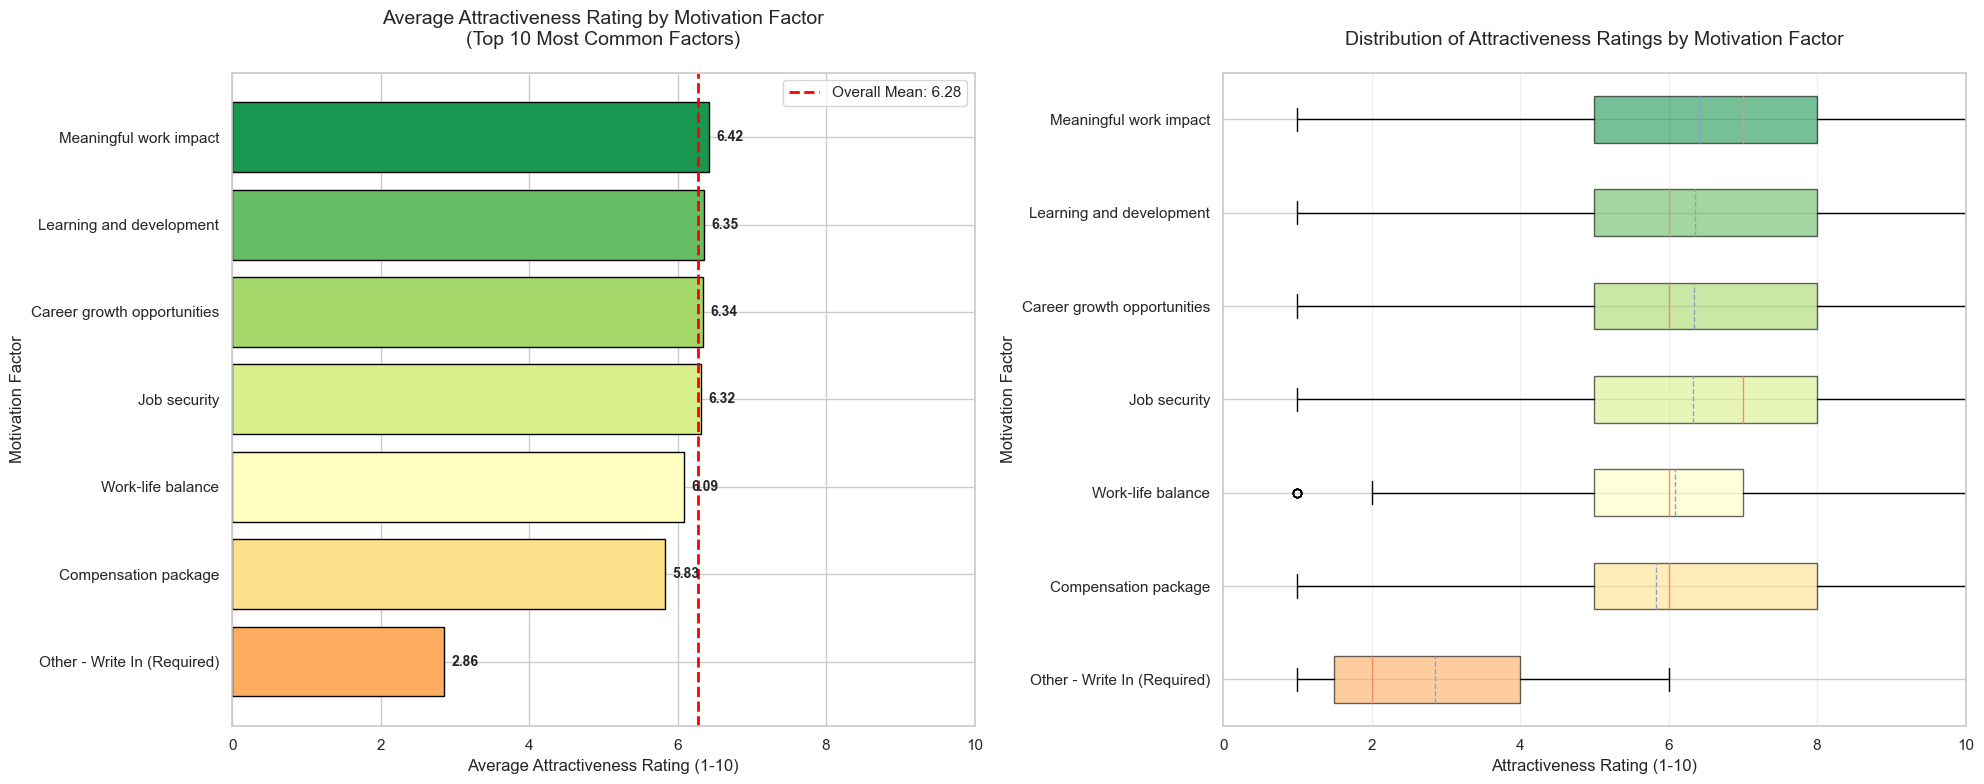

<Figure size 1600x900 with 0 Axes>

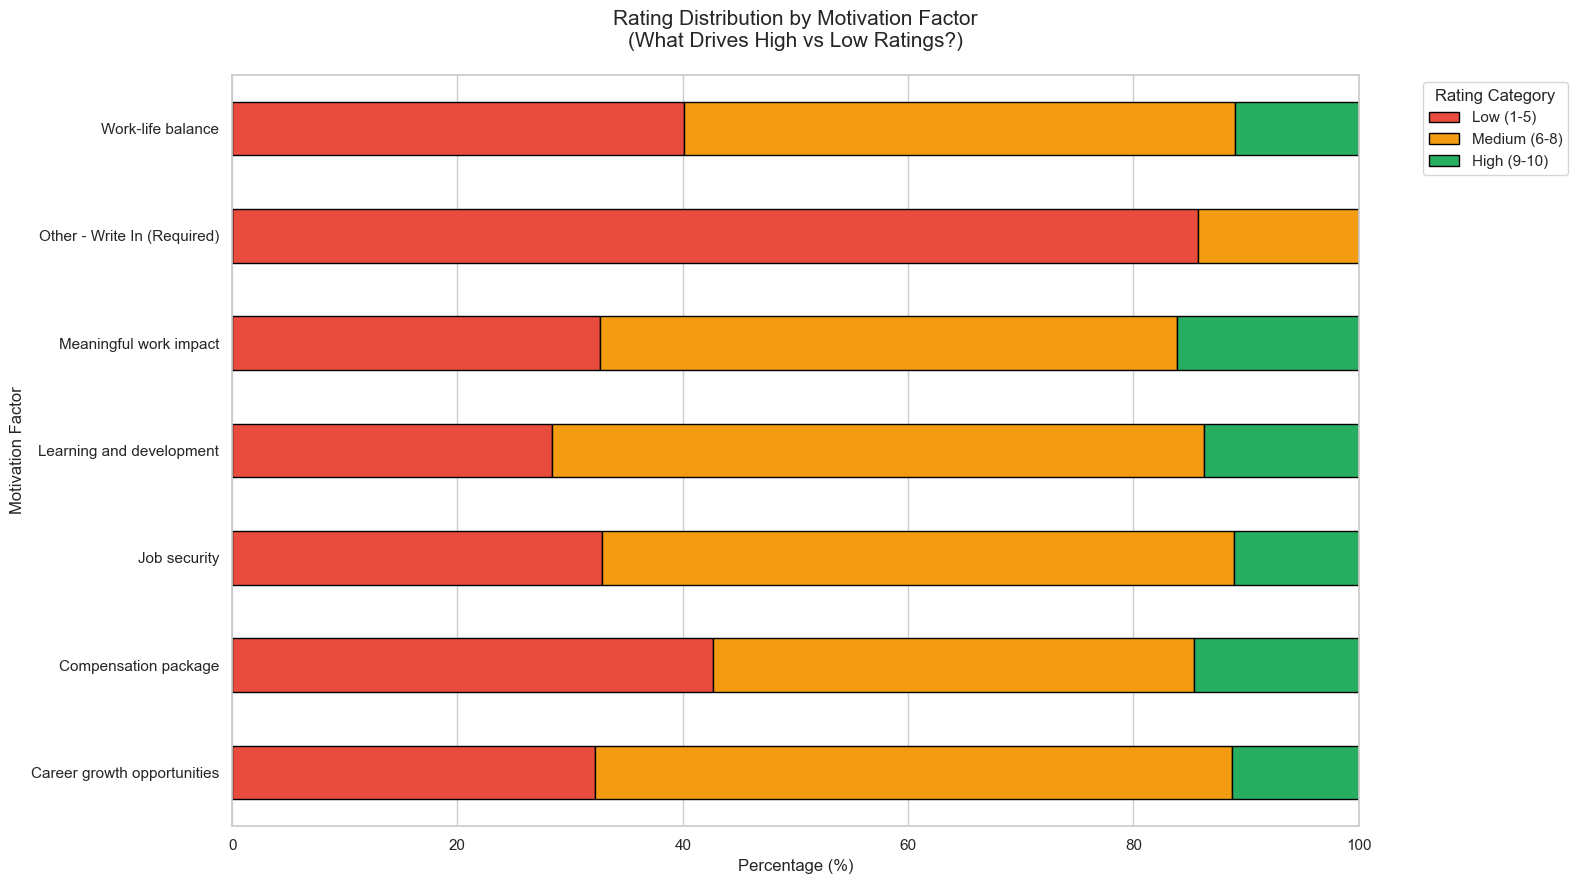


ANALYSIS 4.2: FAMILIARITY DIVIDEND - BRAND AWARENESS ROI

Attractiveness Statistics by Perception Level:
                                                    mean  median  count   std
perception                                                                   
I have a general positive impression of the org...  6.67     7.0    555  1.70
I recognise the organisation by name, but don’t...  5.88     6.0    564  1.80
I’m familiar with the organisation and would co...  7.37     8.0    374  2.19
I’m not familiar enough with the organisation t...  5.16     5.0    355  2.15


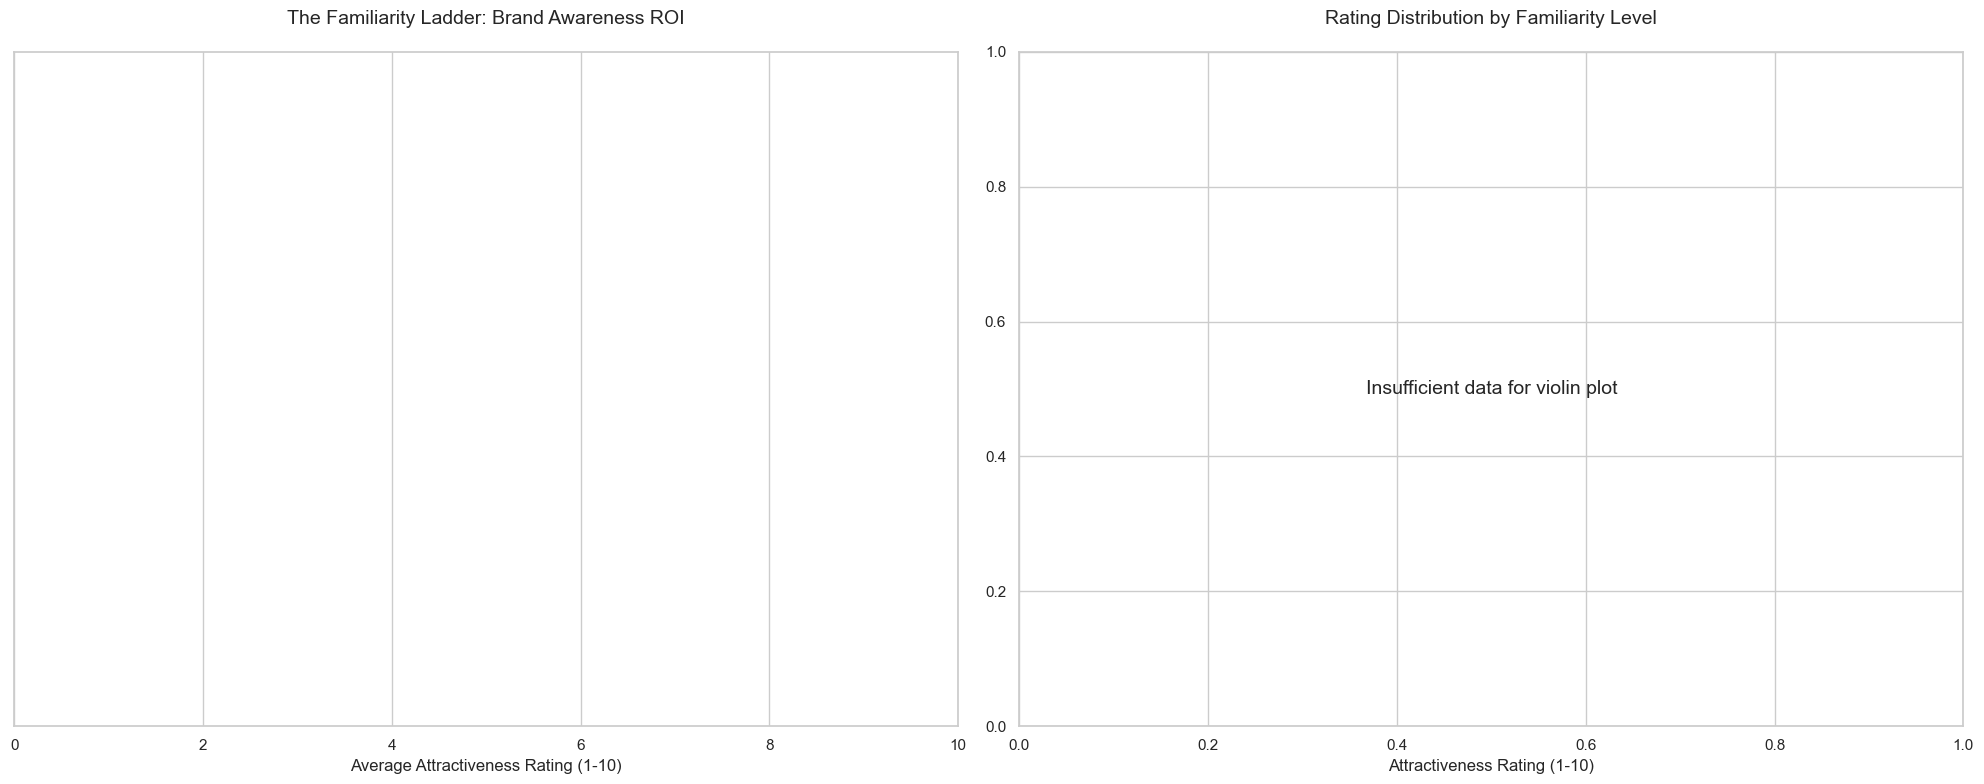


⚠️ Insufficient groups for ANOVA test (need at least 2 groups with data)

ANALYSIS 4.3: INFORMATION GAP ANALYSIS

Information Gap Analysis:
                             Want to Learn (%)  Motivates to Apply (%)  \
Career Progression                   75.054113                0.000000   
Compensation & Benefits              64.393939                0.000000   
Types of Roles                       76.461039               13.690476   
Work-Life Balance & Culture          54.924242               19.155844   
Application Process                  28.896104                0.000000   

                             Gap (Curiosity - Motivation)  
Career Progression                              75.054113  
Compensation & Benefits                         64.393939  
Types of Roles                                  62.770563  
Work-Life Balance & Culture                     35.768398  
Application Process                             28.896104  


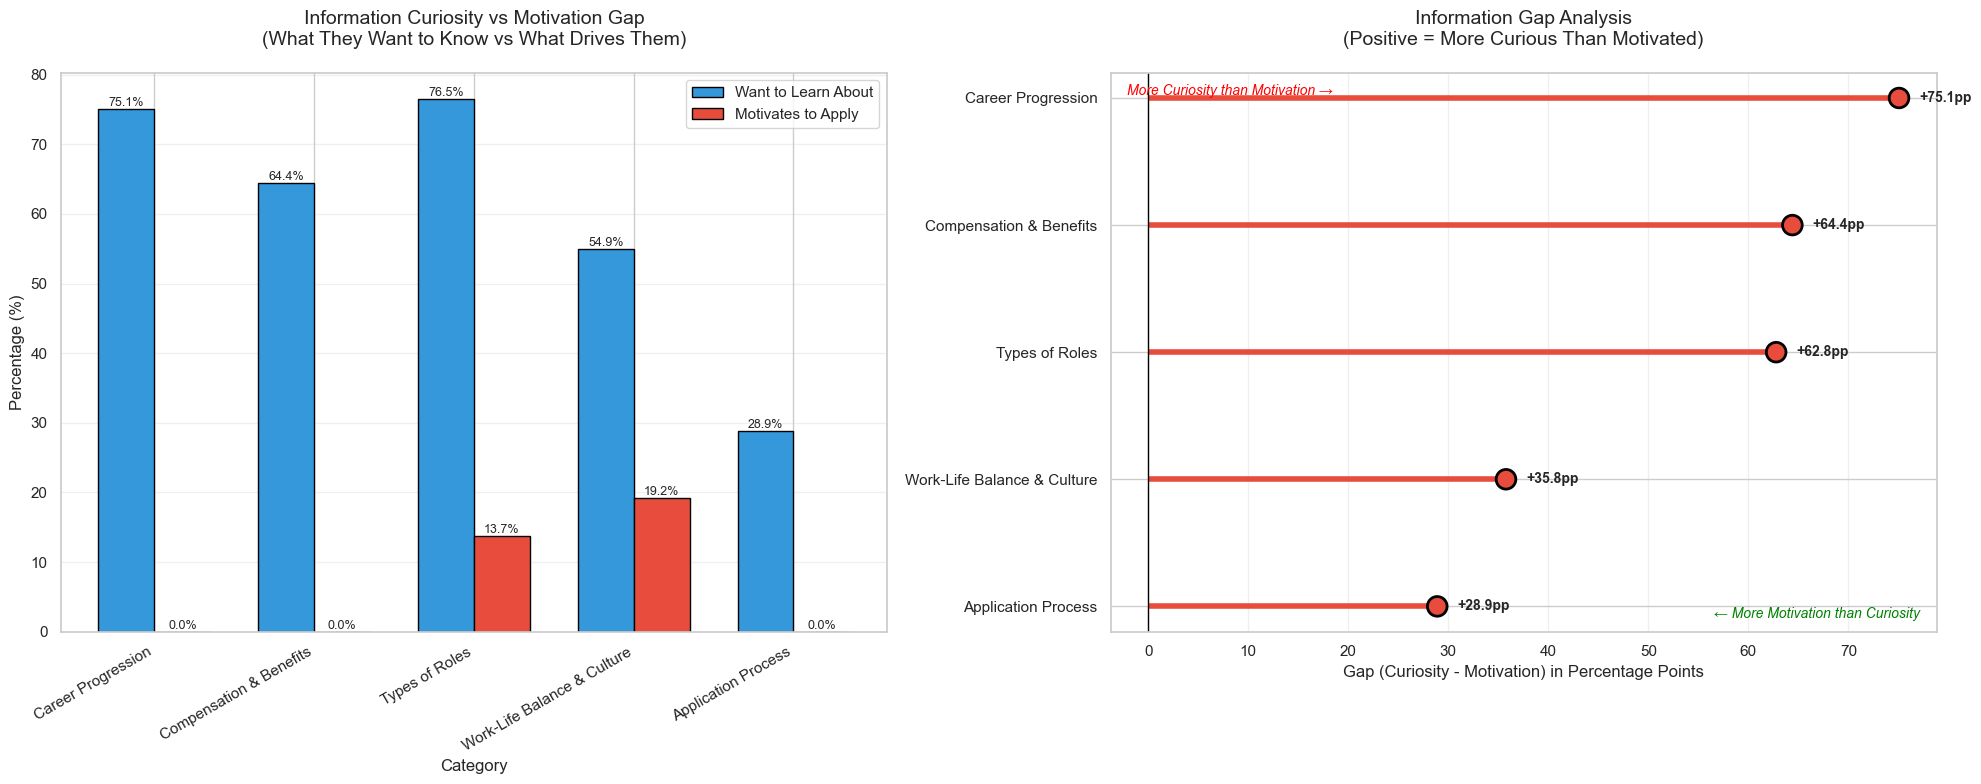


ANALYSIS 4.4: GENDER-BASED MOTIVATION DIFFERENCES

Sample sizes - Male: 686, Female: 1108

Motivation Differences (Female vs Male):
gender                          Female       Male  Difference (F-M)
motivation                                                         
Job security                 15.613718  10.349854          5.263864
Career growth opportunities  22.292419  20.262391          2.030028
Work-life balance            19.855596  18.075802          1.779794
Learning and development      5.595668   5.102041          0.493627
Other - Write In (Required)   0.451264   0.291545          0.159718
Compensation package          4.241877   6.122449         -1.880572
Meaningful work impact       31.949458  39.795918         -7.846460


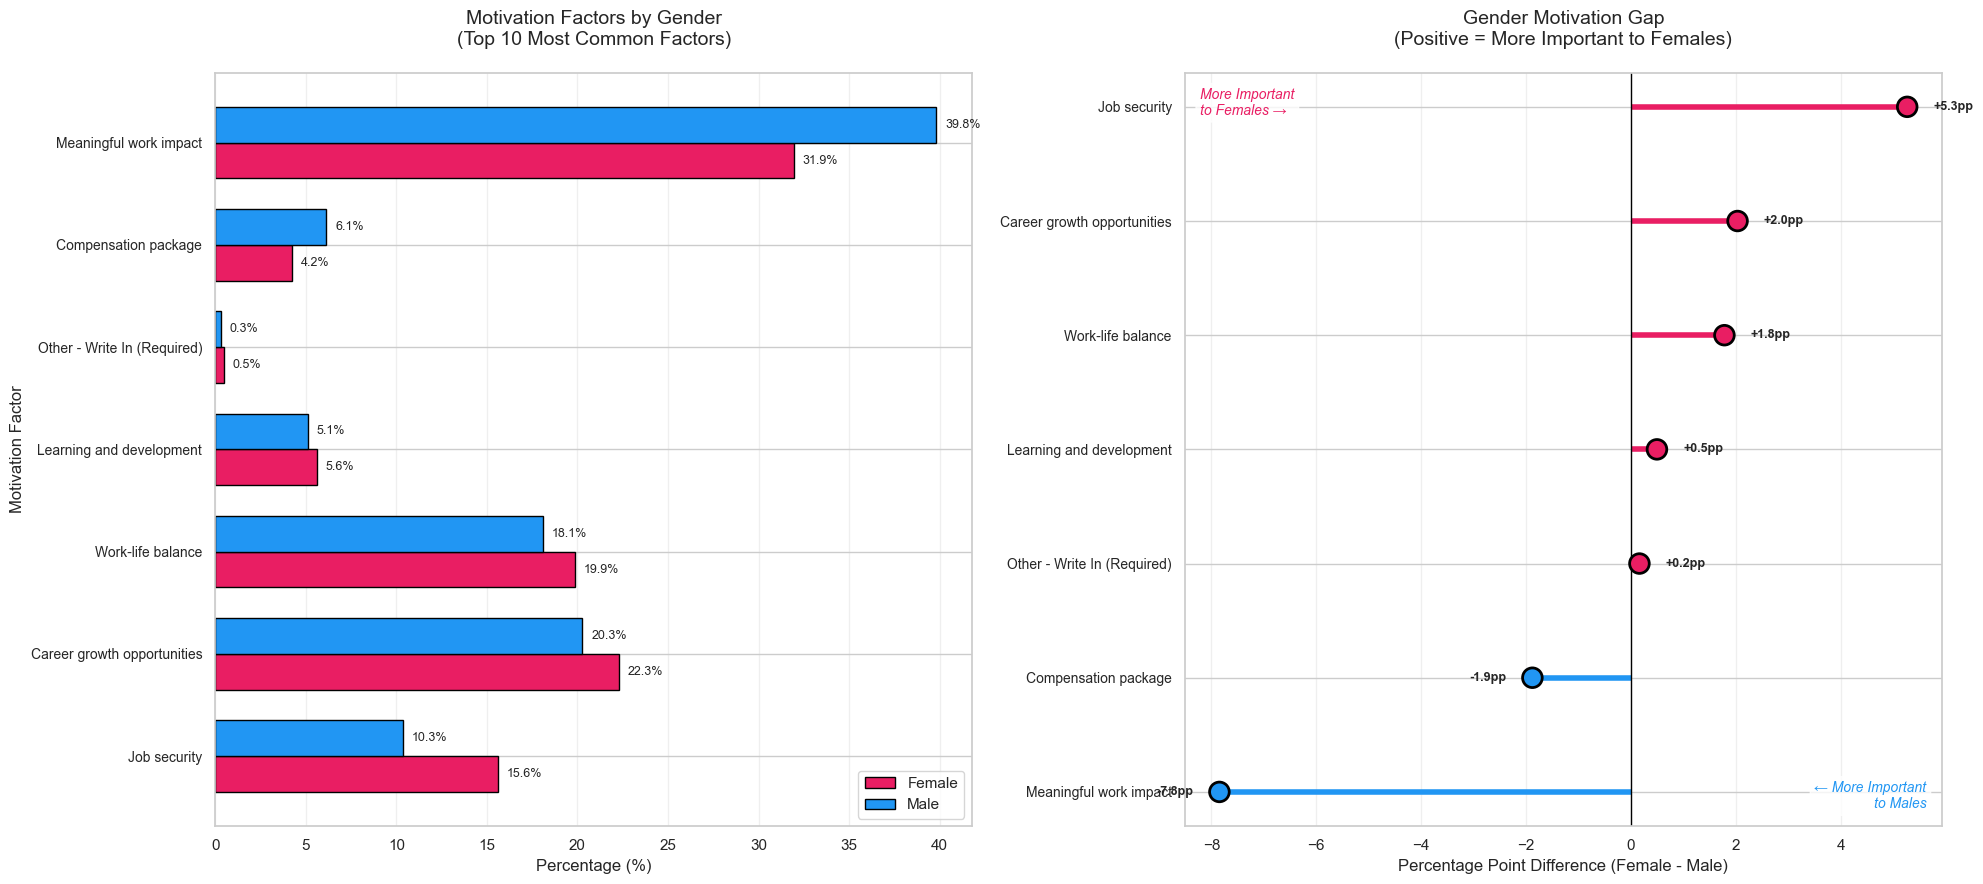

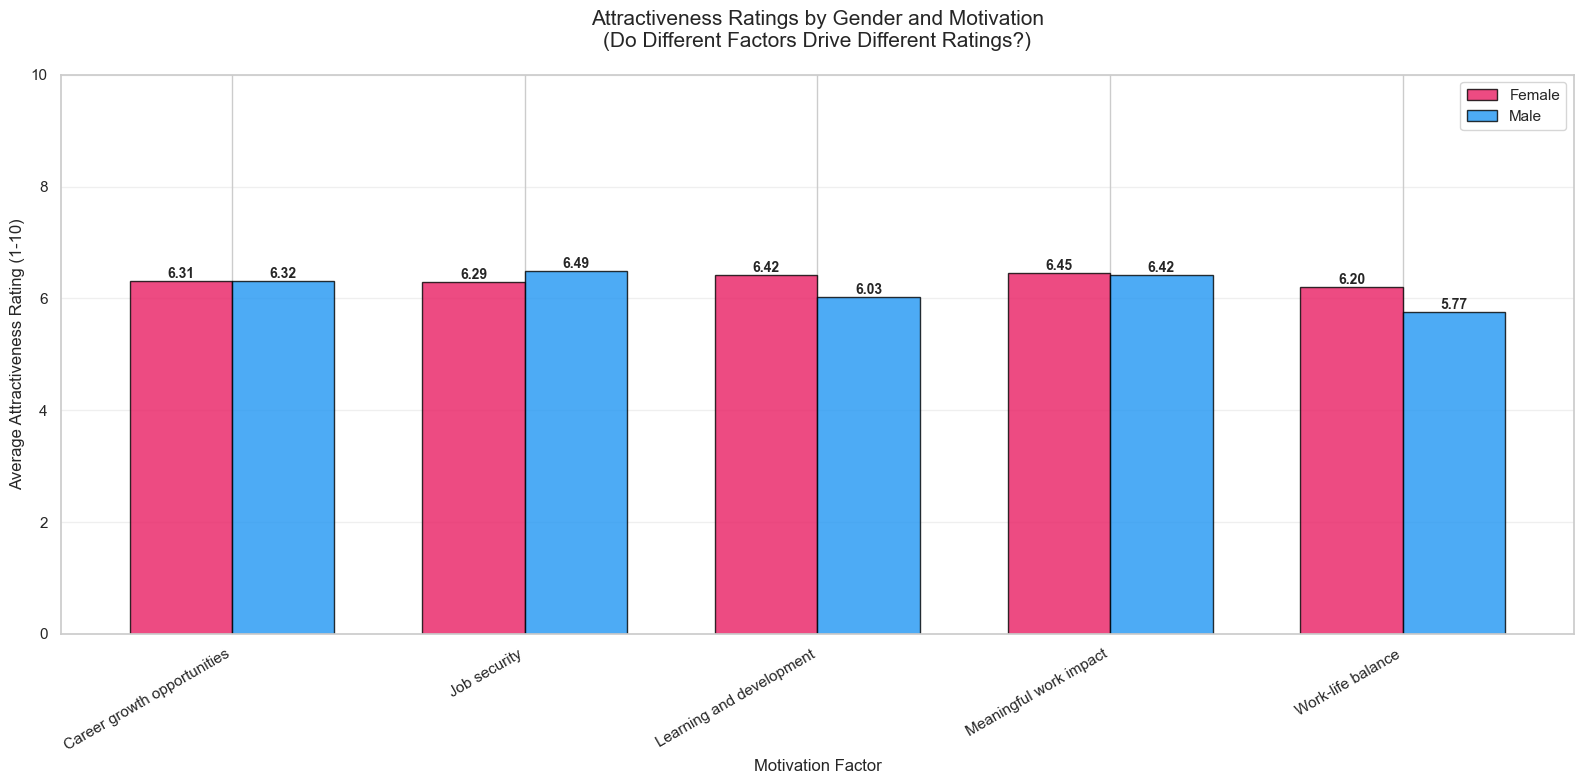


Chi-Square Test - Is there a significant association between gender and motivation?
Chi-square statistic: 21.0946, p-value: 0.001764
✓ Association is statistically significant (p < 0.05)


In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency

sns.set_theme(style="whitegrid", palette="Set2")

print("=" * 80)
print("CATEGORY 4: EMPLOYER ATTRACTIVENESS AND RETENTION")
print("=" * 80)

# ============================================================================
# ANALYSIS 4.1: Driver Analysis - What Motivates High Attractiveness Ratings?
# ============================================================================

print("\n" + "=" * 80)
print("ANALYSIS 4.1: MOTIVATION DRIVERS FOR HIGH ATTRACTIVENESS RATINGS")
print("=" * 80)

# Filter complete responses with valid attractiveness ratings
driver_data = df[(df['status'] == 'Complete') & 
                 (df['attractiveness'].notna()) & 
                 (df['motivation'].notna())].copy()

# Calculate average attractiveness by motivation factor
motivation_attractiveness = driver_data.groupby('motivation')['attractiveness'].agg([
    ('mean', 'mean'),
    ('median', 'median'),
    ('count', 'count'),
    ('std', 'std')
]).round(2)

# Sort by mean attractiveness
motivation_attractiveness = motivation_attractiveness.sort_values('mean', ascending=False)

# Get top 10 motivations by count
top_motivations = driver_data['motivation'].value_counts().head(10).index
motivation_top = motivation_attractiveness[motivation_attractiveness.index.isin(top_motivations)].sort_values('mean', ascending=True)

print("\nTop Motivation Factors by Average Attractiveness Rating:")
print(motivation_attractiveness.head(10))

# Visualization 4.1.1: Average Attractiveness by Motivation Factor
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Bar chart
colors_gradient = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(motivation_top)))
bars = axes[0].barh(motivation_top.index, motivation_top['mean'], color=colors_gradient, edgecolor='black')
axes[0].set_xlabel('Average Attractiveness Rating (1-10)', fontsize=12)
axes[0].set_ylabel('Motivation Factor', fontsize=12)
axes[0].set_title('Average Attractiveness Rating by Motivation Factor\n(Top 10 Most Common Factors)', 
                  fontsize=14, pad=20)
axes[0].set_xlim(0, 10)
axes[0].axvline(driver_data['attractiveness'].mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Overall Mean: {driver_data["attractiveness"].mean():.2f}')
axes[0].legend()

# Add value labels
for i, (idx, row) in enumerate(motivation_top.iterrows()):
    axes[0].text(row['mean'] + 0.1, i, f'{row["mean"]:.2f}', 
                va='center', fontweight='bold', fontsize=10)

# Box plot showing distribution
motivation_list = motivation_top.index.tolist()
data_to_plot = [driver_data[driver_data['motivation'] == m]['attractiveness'].values 
                for m in motivation_list]

bp = axes[1].boxplot(data_to_plot, labels=motivation_list, vert=False, patch_artist=True,
                     showmeans=True, meanline=True)

# Color the boxes
for patch, color in zip(bp['boxes'], colors_gradient):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

axes[1].set_xlabel('Attractiveness Rating (1-10)', fontsize=12)
axes[1].set_ylabel('Motivation Factor', fontsize=12)
axes[1].set_title('Distribution of Attractiveness Ratings by Motivation Factor', 
                  fontsize=14, pad=20)
axes[1].set_xlim(0, 10)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Visualization 4.1.2: High Raters (9-10) vs Low Raters (1-5)
driver_data['rating_category'] = pd.cut(driver_data['attractiveness'], 
                                         bins=[0, 5, 8, 10], 
                                         labels=['Low (1-5)', 'Medium (6-8)', 'High (9-10)'])

rating_motivation = pd.crosstab(driver_data['motivation'], 
                                driver_data['rating_category'], 
                                normalize='index') * 100

# Filter for top motivations
rating_motivation_top = rating_motivation[rating_motivation.index.isin(top_motivations)]

plt.figure(figsize=(16, 9))
rating_motivation_top.plot(kind='barh', stacked=True, 
                           color=['#E74C3C', '#F39C12', '#27AE60'], 
                           edgecolor='black', figsize=(16, 9))
plt.title('Rating Distribution by Motivation Factor\n(What Drives High vs Low Ratings?)', 
          fontsize=15, pad=20)
plt.xlabel('Percentage (%)', fontsize=12)
plt.ylabel('Motivation Factor', fontsize=12)
plt.xlim(0, 100)
plt.legend(title='Rating Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# ============================================================================
# ANALYSIS 4.2: The "Familiarity" Dividend - Brand Awareness ROI
# ============================================================================

print("\n" + "=" * 80)
print("ANALYSIS 4.2: FAMILIARITY DIVIDEND - BRAND AWARENESS ROI")
print("=" * 80)

familiarity_data = df[(df['status'] == 'Complete') & 
                      (df['attractiveness'].notna()) & 
                      (df['perception'].notna())].copy()

# Calculate statistics by perception level
perception_stats = familiarity_data.groupby('perception')['attractiveness'].agg([
    ('mean', 'mean'),
    ('median', 'median'),
    ('count', 'count'),
    ('std', 'std')
]).round(2)

print("\nAttractiveness Statistics by Perception Level:")
print(perception_stats)

# Calculate the "dividend" - difference between perception levels
perception_order = [
    "I don't know much about this organisation.",
    'I know about this organisation but have no opinion on it as an employer.',
    'I think this organisation would be a desirable place to work.',
    'I would apply for a position at this organisation.'
]

# Visualization 4.2.1: Familiarity Ladder
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Ladder chart showing progression
perception_means = familiarity_data.groupby('perception')['attractiveness'].mean()
perception_means = perception_means.reindex(perception_order)

# Filter out NaN values (missing perception levels)
perception_means_clean = perception_means.dropna()
perception_order_clean = perception_means_clean.index.tolist()

colors_familiarity = ['#C0392B', '#E67E22', '#3498DB', '#27AE60'][:len(perception_order_clean)]
bars = axes[0].barh(range(len(perception_order_clean)), perception_means_clean.values, 
                    color=colors_familiarity, edgecolor='black', height=0.6)
axes[0].set_yticks(range(len(perception_order_clean)))
perception_labels = []
for perc in perception_order_clean:
    if "don't know" in perc.lower():
        perception_labels.append('Don\'t Know Much\n(Awareness)')
    elif "no opinion" in perc.lower():
        perception_labels.append('Know, No Opinion\n(Recognition)')
    elif "desirable" in perc.lower():
        perception_labels.append('Desirable Employer\n(Consideration)')
    elif "would apply" in perc.lower():
        perception_labels.append('Would Apply\n(Intent)')
    else:
        perception_labels.append(perc[:30])

axes[0].set_yticklabels(perception_labels, fontsize=11)
axes[0].set_xlabel('Average Attractiveness Rating (1-10)', fontsize=12)
axes[0].set_title('The Familiarity Ladder: Brand Awareness ROI', fontsize=14, pad=20)
axes[0].set_xlim(0, 10)

# Add value labels and "dividend" arrows
for i, (bar, val) in enumerate(zip(bars, perception_means_clean.values)):
    axes[0].text(val + 0.15, i, f'{val:.2f}', va='center', fontweight='bold', fontsize=12)
    
    # Add arrows showing "dividend" between levels
    if i > 0:
        prev_val = perception_means_clean.values[i-1]
        dividend = val - prev_val
        mid_y = i - 0.5
        axes[0].annotate('', xy=(val, mid_y), xytext=(prev_val, mid_y),
                        arrowprops=dict(arrowstyle='->', lw=2, color='darkgreen'))
        axes[0].text((prev_val + val) / 2, mid_y + 0.15, f'+{dividend:.2f}', 
                    ha='center', fontsize=10, color='darkgreen', fontweight='bold',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Violin plot showing distributions - FIXED VERSION
# Build data only for perception levels that have data
data_violin = []
perception_list_with_data = []
for p in perception_order:
    data_subset = familiarity_data[familiarity_data['perception'] == p]['attractiveness'].values
    if len(data_subset) > 0:  # Only include if there's data
        data_violin.append(data_subset)
        perception_list_with_data.append(p)

# Only plot if we have data
if len(data_violin) > 0:
    parts = axes[1].violinplot(data_violin, positions=range(len(data_violin)), 
                               vert=False, widths=0.7, showmeans=True, showmedians=True)
    
    # Color the violins (adjust colors to match number of groups)
    colors_for_violin = ['#C0392B', '#E67E22', '#3498DB', '#27AE60'][:len(data_violin)]
    for patch, color in zip(parts['bodies'], colors_for_violin):
        patch.set_facecolor(color)
        patch.set_alpha(0.5)
    
    axes[1].set_yticks(range(len(perception_list_with_data)))
    ytick_labels = []
    for p in perception_list_with_data:
        if "don't know" in p.lower():
            ytick_labels.append('Don\'t Know')
        elif "no opinion" in p.lower():
            ytick_labels.append('Know, No Opinion')
        elif "desirable" in p.lower():
            ytick_labels.append('Desirable')
        elif "would apply" in p.lower():
            ytick_labels.append('Would Apply')
        else:
            ytick_labels.append(p[:20])
    
    axes[1].set_yticklabels(ytick_labels, fontsize=11)
    axes[1].set_xlabel('Attractiveness Rating (1-10)', fontsize=12)
    axes[1].set_title('Rating Distribution by Familiarity Level', fontsize=14, pad=20)
    axes[1].set_xlim(0, 10)
    axes[1].grid(axis='x', alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'Insufficient data for violin plot', 
                ha='center', va='center', transform=axes[1].transAxes, fontsize=14)
    axes[1].set_xlabel('Attractiveness Rating (1-10)', fontsize=12)
    axes[1].set_title('Rating Distribution by Familiarity Level', fontsize=14, pad=20)

plt.tight_layout()
plt.show()

# Statistical test - ANOVA (only if we have multiple groups with data)
if len(data_violin) >= 2:
    f_stat, p_value = stats.f_oneway(*data_violin)
    print(f"\nANOVA Test - Are differences statistically significant?")
    print(f"F-statistic: {f_stat:.4f}, p-value: {p_value:.6f}")
    if p_value < 0.05:
        print("✓ Differences are statistically significant (p < 0.05)")
    else:
        print("✗ Differences are not statistically significant (p >= 0.05)")
else:
    print("\n⚠️ Insufficient groups for ANOVA test (need at least 2 groups with data)")


# ============================================================================
# ANALYSIS 4.3: Information Gap Analysis - Curiosity vs Motivation
# ============================================================================

print("\n" + "=" * 80)
print("ANALYSIS 4.3: INFORMATION GAP ANALYSIS")
print("=" * 80)

gap_data = df[df['status'] == 'Complete'].copy()

# Calculate "Want to Learn" rates
info_interest_rates = {}
info_cols = ['info_roles', 'info_career', 'info_comp', 'info_culture', 'info_process']
info_names = {
    'info_roles': 'Types of Roles',
    'info_career': 'Career Progression',
    'info_comp': 'Compensation & Benefits',
    'info_culture': 'Work-Life Balance & Culture',
    'info_process': 'Application Process'
}

for col in info_cols:
    rate = (gap_data[col].notna().sum() / len(gap_data)) * 100
    info_interest_rates[info_names[col]] = rate

# Calculate "Motivation" rates
motivation_rates = (gap_data['motivation'].value_counts() / len(gap_data)) * 100

# Create mapping between similar concepts
motivation_mapping = {
    'Compensation & Benefits': ['Competitive salary', 'Compensation and benefits', 
                                'Sign-on bonus', 'Performance bonus'],
    'Career Progression': ['Career development and growth opportunities', 
                          'Career progression', 'Professional development'],
    'Work-Life Balance & Culture': ['Work-life balance', 'Company culture', 
                                    'Flexible working arrangements', 'Team environment'],
    'Types of Roles': ['Challenging and interesting work', 'Job security', 
                       'Variety of roles', 'Role diversity'],
    'Application Process': ['Recruitment process', 'Interview process']
}

# Calculate aggregated motivation rates
aggregated_motivation = {}
for category, keywords in motivation_mapping.items():
    total_rate = 0
    for keyword in keywords:
        matches = motivation_rates[motivation_rates.index.str.contains(keyword, case=False, na=False)]
        total_rate += matches.sum()
    aggregated_motivation[category] = total_rate

# Create comparison DataFrame
gap_df = pd.DataFrame({
    'Want to Learn (%)': pd.Series(info_interest_rates),
    'Motivates to Apply (%)': pd.Series(aggregated_motivation)
}).fillna(0)

gap_df['Gap (Curiosity - Motivation)'] = gap_df['Want to Learn (%)'] - gap_df['Motivates to Apply (%)']
gap_df = gap_df.sort_values('Gap (Curiosity - Motivation)', ascending=False)

print("\nInformation Gap Analysis:")
print(gap_df)

# Visualization 4.3.1: Gap Analysis Chart
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Grouped bar chart
x = np.arange(len(gap_df.index))
width = 0.35

bars1 = axes[0].bar(x - width/2, gap_df['Want to Learn (%)'], width, 
                    label='Want to Learn About', color='#3498DB', edgecolor='black')
bars2 = axes[0].bar(x + width/2, gap_df['Motivates to Apply (%)'], width, 
                    label='Motivates to Apply', color='#E74C3C', edgecolor='black')

axes[0].set_xlabel('Category', fontsize=12)
axes[0].set_ylabel('Percentage (%)', fontsize=12)
axes[0].set_title('Information Curiosity vs Motivation Gap\n(What They Want to Know vs What Drives Them)', 
                  fontsize=14, pad=20)
axes[0].set_xticks(x)
axes[0].set_xticklabels(gap_df.index, rotation=30, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

# Gap visualization (lollipop chart)
gap_sorted = gap_df.sort_values('Gap (Curiosity - Motivation)')
colors_gap = ['#27AE60' if x < 0 else '#E74C3C' for x in gap_sorted['Gap (Curiosity - Motivation)']]

axes[1].hlines(y=range(len(gap_sorted)), xmin=0, xmax=gap_sorted['Gap (Curiosity - Motivation)'], 
               color=colors_gap, linewidth=4)
axes[1].scatter(gap_sorted['Gap (Curiosity - Motivation)'], range(len(gap_sorted)), 
                color=colors_gap, s=200, zorder=3, edgecolor='black', linewidth=2)

axes[1].axvline(0, color='black', linestyle='-', linewidth=1)
axes[1].set_yticks(range(len(gap_sorted)))
axes[1].set_yticklabels(gap_sorted.index, fontsize=11)
axes[1].set_xlabel('Gap (Curiosity - Motivation) in Percentage Points', fontsize=12)
axes[1].set_title('Information Gap Analysis\n(Positive = More Curious Than Motivated)', 
                  fontsize=14, pad=20)
axes[1].grid(axis='x', alpha=0.3)

# Add value labels
for i, (idx, row) in enumerate(gap_sorted.iterrows()):
    gap_val = row['Gap (Curiosity - Motivation)']
    axes[1].text(gap_val + (2 if gap_val > 0 else -2), i, f'{gap_val:+.1f}pp', 
                va='center', ha='left' if gap_val > 0 else 'right', 
                fontweight='bold', fontsize=10)

# Add annotations
axes[1].text(0.98, 0.02, '← More Motivation than Curiosity', 
            transform=axes[1].transAxes, ha='right', va='bottom', 
            fontsize=10, style='italic', color='green')
axes[1].text(0.02, 0.98, 'More Curiosity than Motivation →', 
            transform=axes[1].transAxes, ha='left', va='top', 
            fontsize=10, style='italic', color='red')

plt.tight_layout()
plt.show()


# ============================================================================
# ANALYSIS 4.4: Gender-Based Motivation Differences
# ============================================================================

print("\n" + "=" * 80)
print("ANALYSIS 4.4: GENDER-BASED MOTIVATION DIFFERENCES")
print("=" * 80)

gender_data = df[(df['status'] == 'Complete') & 
                 (df['gender'].notna()) & 
                 (df['motivation'].notna())].copy()

# Focus on Male and Female (exclude "Prefer not to say" if sample size is small)
gender_main = gender_data[gender_data['gender'].isin(['Male', 'Female'])].copy()

print(f"\nSample sizes - Male: {(gender_main['gender'] == 'Male').sum()}, "
      f"Female: {(gender_main['gender'] == 'Female').sum()}")

# Get top motivations overall
top_motivations_gender = gender_main['motivation'].value_counts().head(10).index

# Calculate motivation rates by gender
motivation_by_gender = pd.crosstab(gender_main['motivation'], 
                                    gender_main['gender'], 
                                    normalize='columns') * 100

motivation_by_gender_top = motivation_by_gender[motivation_by_gender.index.isin(top_motivations_gender)]
motivation_by_gender_top['Difference (F-M)'] = (motivation_by_gender_top.get('Female', 0) - 
                                                 motivation_by_gender_top.get('Male', 0))
motivation_by_gender_top = motivation_by_gender_top.sort_values('Difference (F-M)', ascending=False)

print("\nMotivation Differences (Female vs Male):")
print(motivation_by_gender_top)

# Visualization 4.4.1: Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# Grouped bar chart
x = np.arange(len(motivation_by_gender_top.index))
width = 0.35

if 'Female' in motivation_by_gender_top.columns and 'Male' in motivation_by_gender_top.columns:
    bars1 = axes[0].barh(x - width/2, motivation_by_gender_top['Female'], width, 
                        label='Female', color='#E91E63', edgecolor='black')
    bars2 = axes[0].barh(x + width/2, motivation_by_gender_top['Male'], width, 
                        label='Male', color='#2196F3', edgecolor='black')
    
    axes[0].set_xlabel('Percentage (%)', fontsize=12)
    axes[0].set_ylabel('Motivation Factor', fontsize=12)
    axes[0].set_title('Motivation Factors by Gender\n(Top 10 Most Common Factors)', 
                      fontsize=14, pad=20)
    axes[0].set_yticks(x)
    axes[0].set_yticklabels(motivation_by_gender_top.index, fontsize=10)
    axes[0].legend()
    axes[0].grid(axis='x', alpha=0.3)
    
    # Add value labels
    for bars in [bars1, bars2]:
        for i, bar in enumerate(bars):
            width_val = bar.get_width()
            axes[0].text(width_val + 0.5, bar.get_y() + bar.get_height()/2,
                        f'{width_val:.1f}%', ha='left', va='center', fontsize=9)

# Difference chart (lollipop)
diff_sorted = motivation_by_gender_top.sort_values('Difference (F-M)')
colors_diff = ['#2196F3' if x < 0 else '#E91E63' for x in diff_sorted['Difference (F-M)']]

axes[1].hlines(y=range(len(diff_sorted)), xmin=0, xmax=diff_sorted['Difference (F-M)'], 
               color=colors_diff, linewidth=4)
axes[1].scatter(diff_sorted['Difference (F-M)'], range(len(diff_sorted)), 
                color=colors_diff, s=200, zorder=3, edgecolor='black', linewidth=2)

axes[1].axvline(0, color='black', linestyle='-', linewidth=1)
axes[1].set_yticks(range(len(diff_sorted)))
axes[1].set_yticklabels(diff_sorted.index, fontsize=10)
axes[1].set_xlabel('Percentage Point Difference (Female - Male)', fontsize=12)
axes[1].set_title('Gender Motivation Gap\n(Positive = More Important to Females)', 
                  fontsize=14, pad=20)
axes[1].grid(axis='x', alpha=0.3)

# Add value labels
for i, (idx, row) in enumerate(diff_sorted.iterrows()):
    diff_val = row['Difference (F-M)']
    axes[1].text(diff_val + (0.5 if diff_val > 0 else -0.5), i, f'{diff_val:+.1f}pp', 
                va='center', ha='left' if diff_val > 0 else 'right', 
                fontweight='bold', fontsize=9)

# Add annotations
axes[1].text(0.02, 0.98, 'More Important\nto Females →', 
            transform=axes[1].transAxes, ha='left', va='top', 
            fontsize=10, style='italic', color='#E91E63',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
axes[1].text(0.98, 0.02, '← More Important\nto Males', 
            transform=axes[1].transAxes, ha='right', va='bottom', 
            fontsize=10, style='italic', color='#2196F3',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Visualization 4.4.2: Attractiveness ratings by gender and motivation
plt.figure(figsize=(16, 8))

# Get top 5 motivations
top_5_motivations = gender_main['motivation'].value_counts().head(5).index
gender_motivation_attract = gender_main[gender_main['motivation'].isin(top_5_motivations)].groupby(
    ['motivation', 'gender'])['attractiveness'].mean().unstack()

if 'Female' in gender_motivation_attract.columns and 'Male' in gender_motivation_attract.columns:
    x = np.arange(len(gender_motivation_attract.index))
    width = 0.35
    
    bars1 = plt.bar(x - width/2, gender_motivation_attract['Female'], width, 
                    label='Female', color='#E91E63', edgecolor='black', alpha=0.8)
    bars2 = plt.bar(x + width/2, gender_motivation_attract['Male'], width, 
                    label='Male', color='#2196F3', edgecolor='black', alpha=0.8)
    
    plt.xlabel('Motivation Factor', fontsize=12)
    plt.ylabel('Average Attractiveness Rating (1-10)', fontsize=12)
    plt.title('Attractiveness Ratings by Gender and Motivation\n(Do Different Factors Drive Different Ratings?)', 
              fontsize=15, pad=20)
    plt.xticks(x, gender_motivation_attract.index, rotation=30, ha='right')
    plt.ylim(0, 10)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Chi-square test for gender and motivation association
contingency_table = pd.crosstab(gender_main['gender'], gender_main['motivation'])
chi2, p_value_chi, dof, expected = chi2_contingency(contingency_table)
print(f"\nChi-Square Test - Is there a significant association between gender and motivation?")
print(f"Chi-square statistic: {chi2:.4f}, p-value: {p_value_chi:.6f}")
if p_value_chi < 0.05:
    print("✓ Association is statistically significant (p < 0.05)")
else:
    print("✗ Association is not statistically significant (p >= 0.05)")
